<a href="https://colab.research.google.com/github/sgirabin/iti110projects/blob/main/ITI110_Project_IsakRabin_4466624P.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pre-Requisite

## Dependencies Installation

In [ ]:
!pip install mlflow pyngrok tensorflow-text wordcloud

# Implementation

## Libraries Imports

In [ ]:
# Standard library imports
import os
import getpass
import requests
import subprocess
import time
import zipfile
from collections import Counter
from datetime import datetime

# Third-party library imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
from mlflow.tracking import MlflowClient
from pyngrok import ngrok, conf
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    confusion_matrix, precision_score, recall_score, f1_score
)
from wordcloud import WordCloud

# TensorFlow/Keras imports
import tensorflow as tf
import tensorflow_text as tf_text
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Conv1D, BatchNormalization, MaxPooling1D,
    Dense, Flatten, Dropout, LSTM, SimpleRNN, TextVectorization,
    GRU, Bidirectional
)
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

# Google Colab imports
from google.colab import drive

## Common Variables Declarations

### Google Drive

In [ ]:
# Google Drive Base Path
GOOGLE_DRIVE_BASE_PATH = "/content/drive/MyDrive/NYP/ITI110/Projects"

### Enron Spam Dataset

In [ ]:
# Enron Spam Dataset
ENRON_DOWNLOAD_URL = 'https://github.com/MWiechmann/enron_spam_data/blob/master/enron_spam_data.zip?raw=true'
ENRON_ZIP_FILE_PATH = os.path.join(GOOGLE_DRIVE_BASE_PATH, "Dataset/enron_spam_data.zip")
ENRON_CSV_FILE_PATH = os.path.join(GOOGLE_DRIVE_BASE_PATH, "Dataset/enron_spam_data.csv")

### GloVe Embeddings

In [ ]:
# GloVe embeddings
GLOVE_DOWNLOAD_URL = 'http://nlp.stanford.edu/data/glove.6B.zip'
GLOVE_ZIP_FILE_PATH = os.path.join(GOOGLE_DRIVE_BASE_PATH, "Embeddings/glove.6B.zip")
GLOVE_TXT_FILE_PATH = os.path.join(GOOGLE_DRIVE_BASE_PATH, "Embeddings/glove.6B.100d.txt")

### MLFlow

In [ ]:
# MLFlow Logging Directory
MLFLOW_LOG_DIR = os.path.join(GOOGLE_DRIVE_BASE_PATH, "Logs/")

### Model Save Directory

In [ ]:
# Model Directory
MODELS_SAVE_PATH = os.path.join(GOOGLE_DRIVE_BASE_PATH, "Models/")

### Constant Variables

In [ ]:
# Embedding
EMBEDDING_DIM = 100 # Embedding Dimension

# Training Parameters
BATCH_SIZES = [16, 32]
KERNEL_SIZE = [5]
DENSE = [[256, 128], [128, 64]]
LEARNING_RATES = [0.001, 0.0005, 0.0001]
DROPOUT_RATE = [0.5]

## Function Declarations

### Function: Mount Google Drive

In [ ]:
# Mount Google Drive
def mount_google_drive():
    drive.mount('/content/drive')

### Function: Download and Extract Zip File

In [ ]:
# Download and extract dataset
def download_and_extract(file, zip_file,
                         download_url, target_dir=GOOGLE_DRIVE_BASE_PATH):
    if not os.path.exists(file):
        print(f"File {file} does not exist")
        if not os.path.exists(zip_file):
            print(f"File {zip_file} does not exist")
            print(f"Downloading dataset from {download_url}...")
            response = requests.get(download_url, stream=True)
            with open(zip_file, 'wb') as f:
                f.write(response.content)
        with zipfile.ZipFile(zip_file, 'r') as zip_ref:
            zip_ref.extractall(target_dir)
        print(f"Dataset {zip_file} extracted successfully to {target_dir}!")

### Function: Pre-Processing Text (Email Content)

In [ ]:
# Preprocess text and handle missing values
def pre_process_texts(texts):
    # Convert all non-string entries to empty strings
    texts = texts.fillna("").astype(str)

    # Convert all string to lower case
    texts = texts.str.lower()

    # Replace punctuation, special symbolds
    texts = texts.str.replace(r'[^\w\s]', '', regex=True)

    # Replace \n character with space
    texts = texts.str.replace(r'\n', ' ', regex=True)

    # Replace number (0,1,2,3...9) to NUMBER
    texts = texts.str.replace(r'\d+', 'NUMBER', regex=True)

    # Replace url (http://xyz) to URL
    texts = texts.str.replace(r'http\S+|www\S+', 'URL', regex=True)
    return texts

### Function: Tokenize Email Content and apply Padding

In [ ]:
# Tokenization and padding
def tokenize_and_pad(texts, vocab_size, max_length):

    # Define the TextVectorization layer
    vectorize_layer = TextVectorization (
        max_tokens=vocab_size,
        output_mode="int",
        output_sequence_length=max_length
    )

    # Learn the vocabulary from the texts
    vectorize_layer.adapt(texts)

    # Convert texts into padded sequences
    padded = vectorize_layer(texts)

    return padded, vectorize_layer

### Function: Build CNN Model

In [ ]:
# Build CNN model
@mlflow.trace
def build_cnn(vocab_size, embedding_matrix, learning_rate=0.001,
              filters=128, kernel_size=5, pool_size=2,
              dense_units=[128, 64], dropout_rate=0.5, trainable=False,
              optimizer_type="adam"):

    model = Sequential([
        # Pre-trained GloVe Embedding Layer (now configurable)
        Embedding(vocab_size, EMBEDDING_DIM,
                  weights=[embedding_matrix], trainable=trainable),

        # Convolutional Layer (configurable filters & kernel size)
        Conv1D(filters=filters, kernel_size=kernel_size, activation='relu',
               kernel_regularizer=l2(0.01)),
        BatchNormalization(),
        MaxPooling1D(pool_size=pool_size),

        # Flatten to prepare for dense layers
        Flatten(),

        # Fully Connected Layers (configurable dense units & dropout)
        Dense(dense_units[0], activation='relu', kernel_regularizer=l2(0.01)),
        Dropout(dropout_rate),
        Dense(dense_units[1], activation='relu'),
        Dropout(dropout_rate),

        # Output Layer for Binary Classification
        Dense(1, activation='sigmoid')
    ])

    # Configurable Optimizer
    optimizers = {
        "adam": Adam(learning_rate=learning_rate)
    }
    model.compile(optimizer=optimizers[optimizer_type],
                  loss='binary_crossentropy', metrics=['accuracy'])

    model.summary()

    return model

### Function: Build CNN + LTSM Model

In [ ]:
# Model for Hybrid CNN + LSTM
@mlflow.trace
def build_cnn_ltsm(vocab_size, embedding_matrix, learning_rate=0.001,
              filters=128, kernel_size=5, pool_size=2,
              dense_units=[128, 64], dropout_rate=0.5, trainable=False,
              optimizer_type="adam"):

    model = Sequential([
        # Pre-trained GloVe Embedding Layer (now configurable)
        Embedding(vocab_size, EMBEDDING_DIM,
                  weights=[embedding_matrix], trainable=trainable),

        # Convolutional Layer (configurable filters & kernel size)
        Conv1D(filters=filters, kernel_size=kernel_size, activation='relu',
               padding = 'same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=pool_size),

        # Replace two LSTMs with a single Bidirectional LSTM
        Bidirectional(LSTM(128, return_sequences=False)),

        # Fully Connected Layers (configurable dense units & dropout)
        Dense(dense_units[0], activation='relu'),
        Dropout(dropout_rate),
        Dense(dense_units[1], activation='relu'),
        Dropout(dropout_rate),

        # Output Layer for Binary Classification
        Dense(1, activation='sigmoid')
    ])

    # Configurable Optimizer
    optimizers = {
        "adam": Adam(learning_rate=learning_rate)
    }
    model.compile(optimizer=optimizers[optimizer_type],
                  loss='binary_crossentropy', metrics=['accuracy'])

    model.summary()

    return model

### Function: Build RNN + LTSM Model

In [ ]:
# Model for RNN + LSTM
@mlflow.trace
def build_rnn_lstm(vocab_size, embedding_matrix, learning_rate=0.001,
              dense_units=[128, 64], dropout_rate=0.5, trainable=False,
              optimizer_type="adam"):
    model = Sequential([
        # Pre-trained GloVe Embedding Layer (now configurable)
        Embedding(vocab_size, EMBEDDING_DIM,
                  weights=[embedding_matrix], trainable=trainable),

        # GRU
        #GRU(128, return_sequences=True),

        # Replace two LSTMs with a single Bidirectional LSTM
        Bidirectional(LSTM(128, return_sequences=False)),

        # Fully Connected Layers (configurable dense units & dropout)
        Dense(dense_units[0], activation='relu'),
        Dropout(dropout_rate),
        Dense(dense_units[1], activation='relu'),
        Dropout(dropout_rate),

        # Output Layer for Binary Classification
        Dense(1, activation='sigmoid')
    ])

    # Configurable Optimizer
    optimizers = {
        "adam": Adam(learning_rate=learning_rate)
    }
    model.compile(optimizer=optimizers[optimizer_type],
                  loss='binary_crossentropy', metrics=['accuracy'])

    model.summary()

    return model

### Function: Model Training and Evaluation

In [ ]:
# Train and Evaluate Model
@mlflow.trace
def train_and_evaluate(model, model_name, lr,
                       X_train, y_train, X_val, y_val, X_test, y_test):

    for batch_size in BATCH_SIZES:

      timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
      experiment_name = f"EnronSpam_{model_name}_{timestamp}_LR_{lr}_Batch_{batch_size}"

      mlflow.set_experiment(experiment_name=f"{model_name} with LR {lr} and Batch {batch_size}")

      with mlflow.start_run():
          mlflow.log_param("batch_size", batch_size)
          mlflow.log_param("learning_rate", lr)

          early_stopping = EarlyStopping(monitor='val_loss', patience=5,
                                         restore_best_weights=True)

          history = model.fit(X_train, y_train,
                              validation_data=(X_val, y_val),
                              epochs=50,
                              batch_size=batch_size,
                              callbacks=[early_stopping])

          # Log metrics
          for epoch, logs in enumerate(history.history['accuracy']):
              mlflow.log_metric("train_accuracy", logs, step=epoch)
          for epoch, logs in enumerate(history.history['val_accuracy']):
              mlflow.log_metric("val_accuracy", logs, step=epoch)
          for epoch, logs in enumerate(history.history['loss']):
              mlflow.log_metric("loss", logs, step=epoch)
          for epoch, logs in enumerate(history.history['val_loss']):
              mlflow.log_metric("val_loss", logs, step=epoch)

          # Evaluate and log loss, accuracy, and predictions
          test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
          predictions = (model.predict(X_test) > 0.5).astype(int)

          precision = precision_score(y_test, predictions)
          recall = recall_score(y_test, predictions)
          f1 = f1_score(y_test, predictions)
          roc_auc = roc_auc_score(y_test, model.predict(X_test))

          print(f"test_loss: {test_loss}")
          print(f"test_accuracy: {test_accuracy}")
          print(f"precision: {precision}")
          print(f"recall: {recall}")
          print(f"f1_score: {f1}")
          print(f"roc_auc: {roc_auc}")

          mlflow.log_metric("test_loss", test_loss)
          mlflow.log_metric("test_accuracy", test_accuracy)
          mlflow.log_metric("precision", precision)
          mlflow.log_metric("recall", recall)
          mlflow.log_metric("f1_score", f1)
          mlflow.log_metric("roc_auc", roc_auc)
          mlflow.log_metric("roc_auc", roc_auc)

          # Print classification report
          report = classification_report(y_test, predictions, target_names=["Ham", "Spam"])
          print(report)

          # Save the model
          model_filename = f"{model_name}_{timestamp}_LR_{lr}_Batch_{batch_size}_{test_accuracy:.4f}"
          model_path = os.path.join(GOOGLE_DRIVE_BASE_PATH, f"Models/{model_filename}.keras")
          model.save(model_path)
          mlflow.log_artifact(model_path)

          print(f"{model_name} - Test Accuracy: {test_accuracy:.4f}, ROC AUC: {roc_auc:.4f}")

          # Confusion Matrix
          cm = confusion_matrix(y_test, predictions)
          sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
          plt.xlabel('Predicted')
          plt.ylabel('Actual')
          plt.title(f'Confusion Matrix - {model_name}')
          plt.show()

          # Accuracy
          plt.plot(history.history['accuracy'], label='Train Accuracy')
          plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
          plt.xlabel('Epochs')
          plt.ylabel('Accuracy')
          plt.legend()
          plt.title(f'{model_name} - Training & Validation Accuracy')
          plt.show()

          # Loss
          plt.plot(history.history['loss'], label='Train Loss')
          plt.plot(history.history['val_loss'], label='Validation Loss')
          plt.xlabel('Epochs')
          plt.ylabel('Loss')
          plt.legend()
          plt.title(f'{model_name} - Training & Validation Loss')
          plt.show()

          # Plot ROC Curve
          fpr, tpr, _ = roc_curve(y_test, predictions)
          plt.figure()
          plt.plot(fpr, tpr, color='blue', label=f"AUC = {roc_auc_score(y_test, predictions):.4f}")
          plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
          plt.title(f'{model_name} - ROC Curve')
          plt.xlabel("False Positive Rate")
          plt.ylabel("True Positive Rate")
          plt.legend()
          plt.show()

# Experiments

## Preparations

### Mount Google Drive

In [ ]:
# Mount Google Drive
mount_google_drive()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Check Enron Spam Dataset

In [ ]:
# Download Enron Spam Dataset if does not exist
enron_target_path = os.path.join(GOOGLE_DRIVE_BASE_PATH, "Dataset/")
download_and_extract(ENRON_CSV_FILE_PATH, ENRON_ZIP_FILE_PATH, ENRON_DOWNLOAD_URL, enron_target_path)

# Read Enron Spam Dataset
data = pd.read_csv(ENRON_CSV_FILE_PATH)

# Display Total Records of Enron Spam Dataset
print(f"Total records: {data.shape[0]}")

# Display the first few rows of the dataset
print("First few rows of the dataset:")
print(data.head())

Total records: 33716
First few rows of the dataset:
   Message ID                       Subject  \
0           0  christmas tree farm pictures   
1           1      vastar resources , inc .   
2           2  calpine daily gas nomination   
3           3                    re : issue   
4           4     meter 7268 nov allocation   

                                             Message Spam/Ham        Date  
0                                                NaN      ham  1999-12-10  
1  gary , production from the high island larger ...      ham  1999-12-13  
2             - calpine daily gas nomination 1 . doc      ham  1999-12-14  
3  fyi - see note below - already done .\nstella\...      ham  1999-12-14  
4  fyi .\n- - - - - - - - - - - - - - - - - - - -...      ham  1999-12-14  


### Confirming Dataset

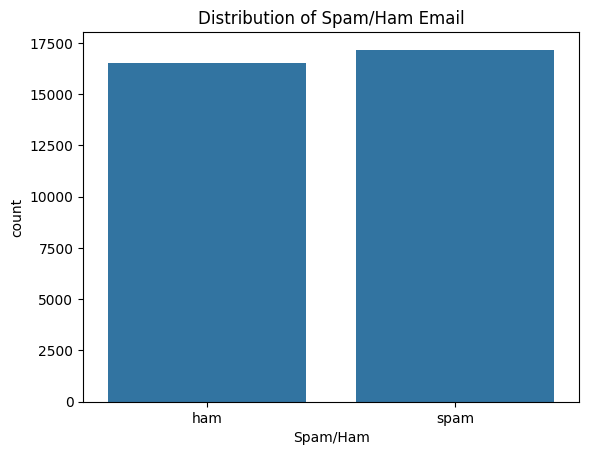

In [ ]:
# Check the distribution of Enron Spam Dataset
sns.countplot(x='Spam/Ham', data=data)
plt.title('Distribution of Spam/Ham Email')
plt.show()

In [ ]:
# Extract only the 'message' column and spam labels
spam_emails = data[data['Spam/Ham'] == 'spam']['Message']
ham_emails = data[data['Spam/Ham'] == 'ham']['Message']

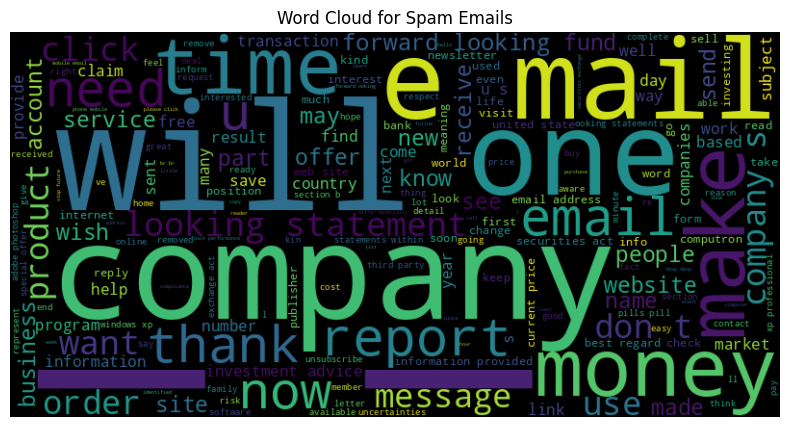

In [ ]:
# Generate Word Cloud for Spam Emails
spam_text = " ".join(spam_emails.astype(str))
spam_wordcloud = WordCloud(width=800, height=400, background_color="black").generate(spam_text)

plt.figure(figsize=(10, 5))
plt.imshow(spam_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud for Spam Emails")
plt.show()

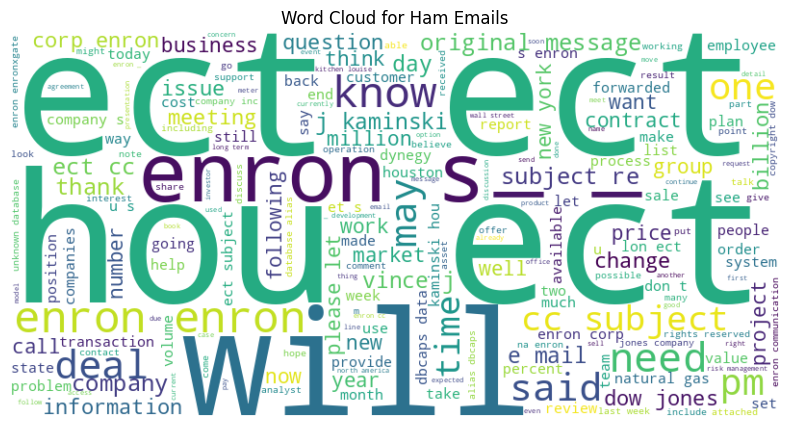

In [ ]:
# Generate Word Cloud for Ham Emails
ham_text = " ".join(ham_emails.astype(str))
ham_wordcloud = WordCloud(width=800, height=400, background_color="white").generate(ham_text)

plt.figure(figsize=(10, 5))
plt.imshow(ham_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud for Ham Emails")
plt.show()

### Data Cleaning: Remove unused features

In [ ]:
# Remove Unecessary Column
data = data.drop(columns=['Message ID', 'Subject', 'Date'])

### Data Cleaning: Preprocessed Email Content

In [ ]:
# Preprocess Enron Spam dataset
print(data['Message'])
data['Message'] = pre_process_texts(data['Message'])
print(data['Message'])

0                                                      NaN
1        gary , production from the high island larger ...
2                   - calpine daily gas nomination 1 . doc
3        fyi - see note below - already done .\nstella\...
4        fyi .\n- - - - - - - - - - - - - - - - - - - -...
                               ...                        
33711    hello , welcome to gigapharm onlinne shop .\np...
33712    i got it earlier than expected and it was wrap...
33713    are you ready to rock on ? let the man in you ...
33714    learn how to last 5 - 10 times longer in\nbed ...
33715    hi : )\ndo you need some softwares ? i can giv...
Name: Message, Length: 33716, dtype: object
0                                                         
1        gary  production from the high island larger b...
2                 calpine daily gas nomination NUMBER  doc
3        fyi  see note below  already done  stella     ...
4        fyi                        forwarded by lauri ...
            

### Data Cleaning: Convert Categorical Data to Numeric

In [ ]:
# Convert Categorical to Numeric for Training
data['Spam/Ham'] = data['Spam/Ham'].apply(lambda x: 1 if x == 'spam' else 0)

### Data Splitting: Training (70%), Validation (15%), Testing (15%)

In [ ]:
X = data['Message']
y = data['Spam/Ham']

In [ ]:
# Split data: Training (70%), Validation (15%), Testing (15%).
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [ ]:
print(f" Training data size = {X_train.shape}")
print(f" Training data size = {X_val.shape}")
print(f" Training data size = {X_test.shape}")

 Training data size = (23601,)
 Training data size = (5057,)
 Training data size = (5058,)


### Dataset Exploratory

In [ ]:
# Count words in the dataset
word_counts = Counter(" ".join(X_train).split())

# Print total unique words
total_unique_words = len(word_counts)
print(f"Total Unique Words in Dataset: {total_unique_words}")

Total Unique Words in Dataset: 120646


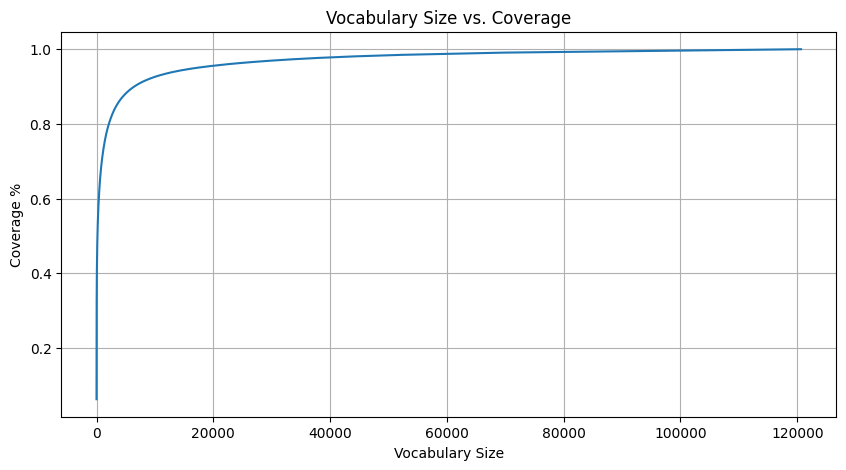

Recommended VOCAB_SIZE for 95% coverage: 17093


In [ ]:
# Get word frequencies sorted in descending order
word_frequencies = np.array(sorted(word_counts.values(), reverse=True))

# Compute cumulative percentage coverage
cumulative_coverage = np.cumsum(word_frequencies) / np.sum(word_frequencies)

# Plot cumulative distribution of vocabulary size
plt.figure(figsize=(10, 5))
plt.plot(cumulative_coverage)
plt.xlabel("Vocabulary Size")
plt.ylabel("Coverage %")
plt.title("Vocabulary Size vs. Coverage")
plt.grid()
plt.show()

# Find vocab size covering 95% of words
optimal_vocab_size = np.argmax(cumulative_coverage >= 0.95) + 1
print(f"Recommended VOCAB_SIZE for 95% coverage: {optimal_vocab_size}")

Max Length: 37136
Average Length: 236.56
95th Percentile: 744.0
99th Percentile: 1543.0


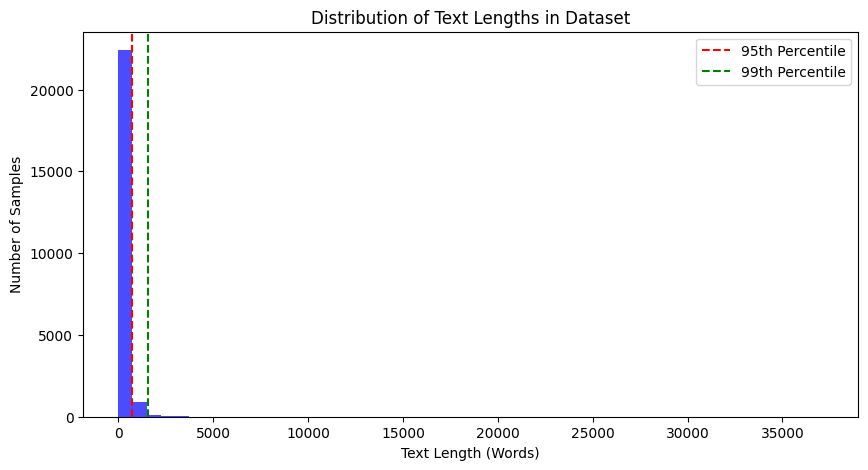

In [ ]:
# Compute text lengths
text_lengths = X_train.apply(lambda x: len(x.split()))  # Count words in each sample

# Print basic statistics
max_length = np.max(text_lengths)
avg_length = np.mean(text_lengths)
percentile05_length = np.percentile(text_lengths, 95)
percentile09_length = np.percentile(text_lengths, 99)

print(f"Max Length: {max_length}")
print(f"Average Length: {avg_length:.2f}")
print(f"95th Percentile: {percentile05_length}")
print(f"99th Percentile: {percentile09_length}")

# Plot text length distribution
plt.figure(figsize=(10, 5))
plt.hist(text_lengths, bins=50, color='blue', alpha=0.7)
plt.axvline(np.percentile(text_lengths, 95), color='red', linestyle='--', label="95th Percentile")
plt.axvline(np.percentile(text_lengths, 99), color='green', linestyle='--', label="99th Percentile")
plt.xlabel("Text Length (Words)")
plt.ylabel("Number of Samples")
plt.title("Distribution of Text Lengths in Dataset")
plt.legend()
plt.show()

### Tokenise and Padding

In [ ]:
# Tokenize and pad
VOCAB_SIZE=optimal_vocab_size
MAX_SEQUENCE_LENGTH=int(percentile05_length)

X_train_padded, vectorize_layer = tokenize_and_pad(X_train,
                                                   vocab_size=VOCAB_SIZE,
                                                   max_length=MAX_SEQUENCE_LENGTH)
X_val_padded = vectorize_layer(X_val)
X_test_padded = vectorize_layer(X_test)

### Prepare Embeddings

In [ ]:
# Download GloVe embeddings, extract if not already downloaded
glove_target_path = os.path.join(GOOGLE_DRIVE_BASE_PATH, "Embeddings/")
download_and_extract(GLOVE_TXT_FILE_PATH, GLOVE_ZIP_FILE_PATH, GLOVE_DOWNLOAD_URL, glove_target_path)

In [ ]:
# Initialize the embedding matrix
vocab = vectorize_layer.get_vocabulary()
print(vectorize_layer)

word_index = {word: i for i, word in enumerate(vocab)}
print(f"Vocabulary Size: {len(word_index)}")

embedding_matrix = np.zeros((len(word_index) + 1, EMBEDDING_DIM))
print(f"Embedding Matrix Shape: {embedding_matrix.shape}")

# Load GloVe embeddings
print("Loading GloVe Word Embedding...")
with open(GLOVE_TXT_FILE_PATH, encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        if word in word_index:
            embedding_matrix[word_index[word]] = coefs
    f.close()

print(f"GloVe embeddings loaded. Matrix size: {embedding_matrix.shape}")

<TextVectorization name=text_vectorization_2, built=True>
Vocabulary Size: 17093
Embedding Matrix Shape: (17094, 100)
Loading GloVe Word Embedding...
GloVe embeddings loaded. Matrix size: (17094, 100)


## Model Training

### Tracking the Experiment

In [ ]:
# Kill existing process if any
! pkill -f ngrok

In [ ]:
# Start the MLflow UI
subprocess.Popen(["mlflow", "ui", "--backend-store-uri", "file://" + MLFLOW_LOG_DIR])

<Popen: returncode: None args: ['mlflow', 'ui', '--backend-store-uri', 'file...>

In [ ]:
# Set MLflow Tracking URI
mlflow.set_tracking_uri("file://" + MLFLOW_LOG_DIR)
conf.get_default().auth_token = "2t8TIG1geBuF6yFcNXZYkkxTqzg_7qGykBf4NYA9AKwvB9u8R"
port=5000
public_url = ngrok.connect(port).public_url

### CNN

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ ?                           │       1,709,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,709,400 (6.52 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,709,400 (6.52 MB)

Epoch 1/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.7979 - loss: 7.9722 - val_accuracy: 0.8153 - val_loss: 2.5534
Epoch 2/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - accuracy: 0.9347 - loss: 1.5253 - val_accuracy: 0.8788 - val_loss: 2.4392
Epoch 3/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.9541 - loss: 1.0323 - val_accuracy: 0.9427 - val_loss: 0.8741
Epoch 4/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.9529 - loss: 0.7398 - val_accuracy: 0.9678 - val_loss: 0.5518
Epoch 5/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.9592 - loss: 0.6070 - val_accuracy: 0.9660 - val_loss: 0.5542
Epoch 6/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.9547 - loss: 0.6341 - val_accuracy: 0.9658 - val_loss: 0.5831
Epoch 7/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.9584 - loss: 0.5447 - val_accuracy: 0.9682 - val_loss: 0.6248
Epoch 8/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.9614 -

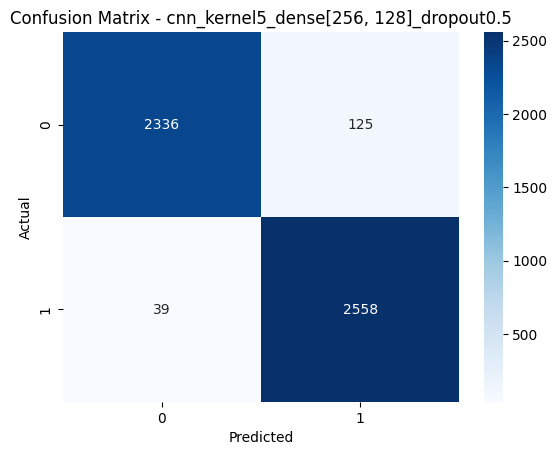

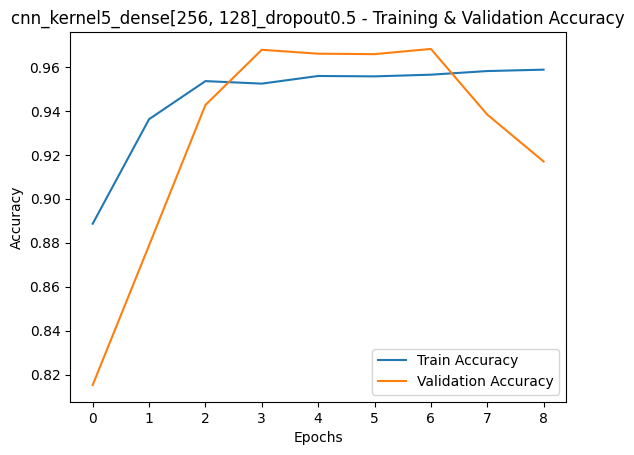

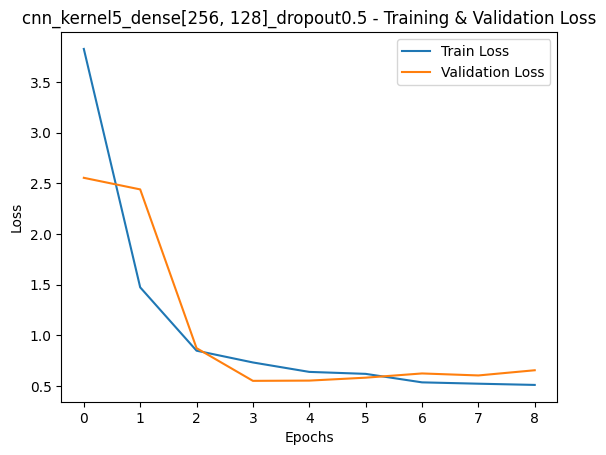

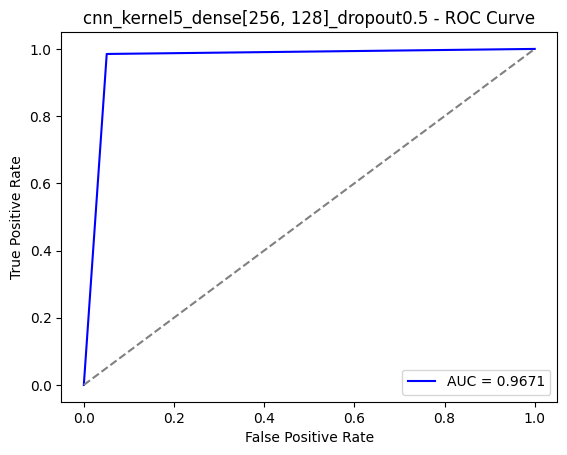

2025/03/01 19:30:48 INFO mlflow.tracking.fluent: Experiment with name 'cnn_kernel5_dense[256, 128]_dropout0.5 with LR 0.001 and Batch 32' does not exist. Creating a new experiment.


Epoch 1/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.9605 - loss: 0.8555 - val_accuracy: 0.9715 - val_loss: 0.3531
Epoch 2/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.9689 - loss: 0.4100 - val_accuracy: 0.9539 - val_loss: 0.4106
Epoch 3/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.9690 - loss: 0.3855 - val_accuracy: 0.9642 - val_loss: 0.3903
Epoch 4/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.9693 - loss: 0.3757 - val_accuracy: 0.9674 - val_loss: 0.4006
Epoch 5/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.9707 - loss: 0.3627 - val_accuracy: 0.9575 - val_loss: 0.4244
Epoch 6/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.9714 - loss: 0.3449 - val_accuracy: 0.9413 - val_loss: 0.4645
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
test_loss: 0.3443625867366791
test_accuracy: 0.9752866625785828
precision: 0.9674735249621785
recall: 0.9849826723142087
f1_score: 0.97614

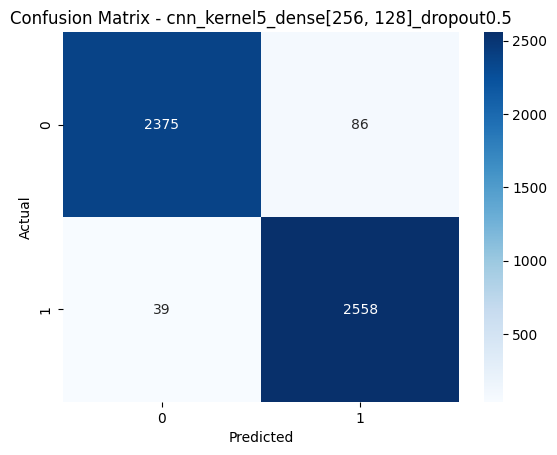

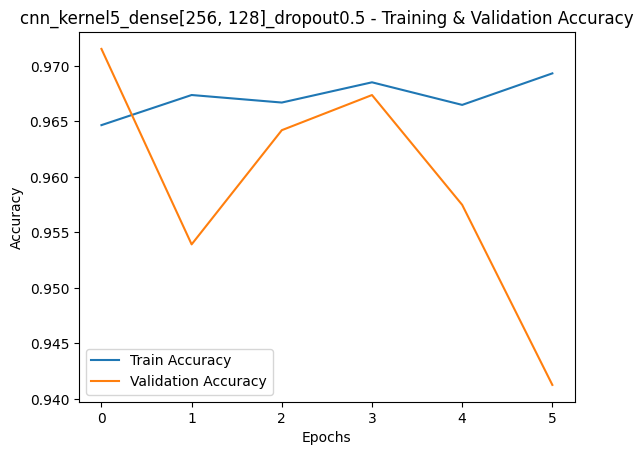

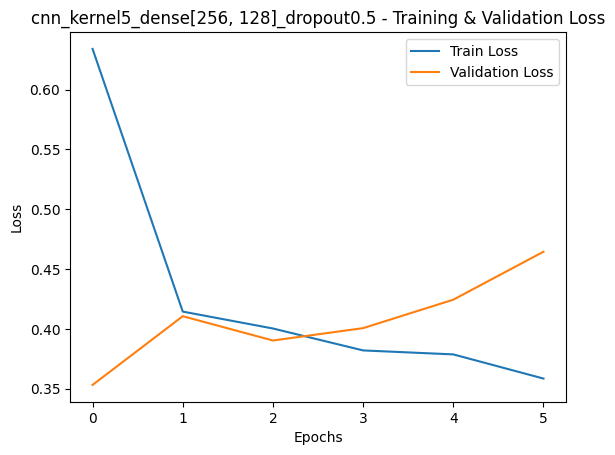

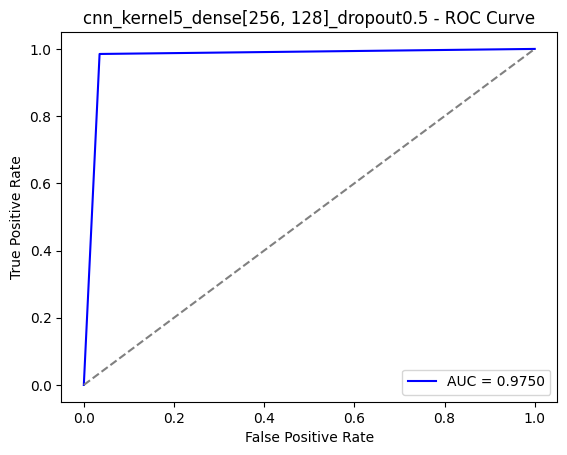

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ ?                           │       1,709,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_3 (MaxPooling1D)       │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,709,400 (6.52 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,709,400 (6.52 MB)

2025/03/01 19:32:47 INFO mlflow.tracking.fluent: Experiment with name 'cnn_kernel5_dense[256, 128]_dropout0.5 with LR 0.0005 and Batch 16' does not exist. Creating a new experiment.


Epoch 1/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 32s 16ms/step - accuracy: 0.7916 - loss: 7.6158 - val_accuracy: 0.9634 - val_loss: 1.3814
Epoch 2/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.9604 - loss: 1.1182 - val_accuracy: 0.9421 - val_loss: 0.9917
Epoch 3/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.9640 - loss: 0.8758 - val_accuracy: 0.9699 - val_loss: 0.9811
Epoch 4/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.9678 - loss: 0.7267 - val_accuracy: 0.9620 - val_loss: 0.6908
Epoch 5/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.9637 - loss: 0.7125 - val_accuracy: 0.9737 - val_loss: 0.4403
Epoch 6/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.9733 - loss: 0.5209 - val_accuracy: 0.9480 - val_loss: 0.5472
Epoch 7/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.9693 - loss: 0.5042 - val_accuracy: 0.9567 - val_loss: 0.5394
Epoch 8/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.9724 -

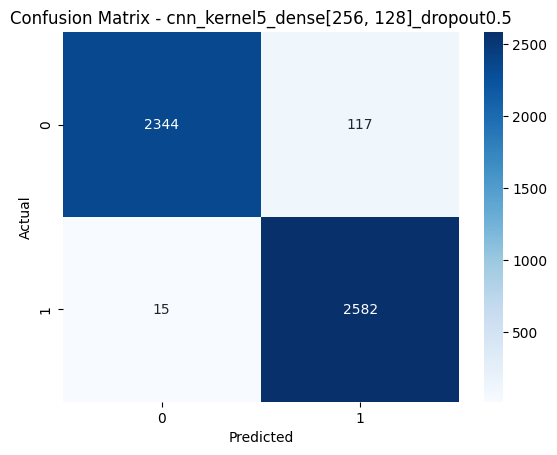

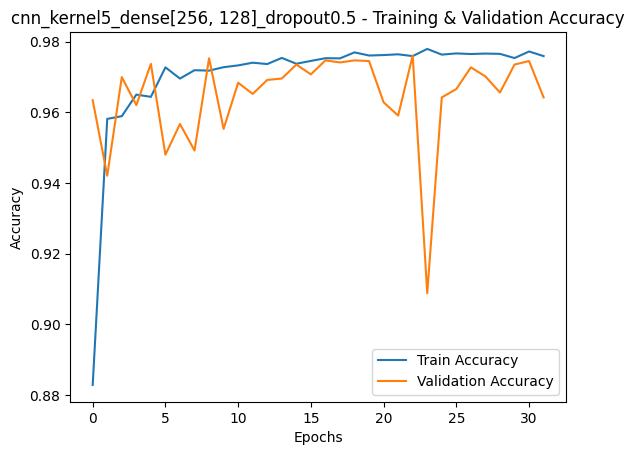

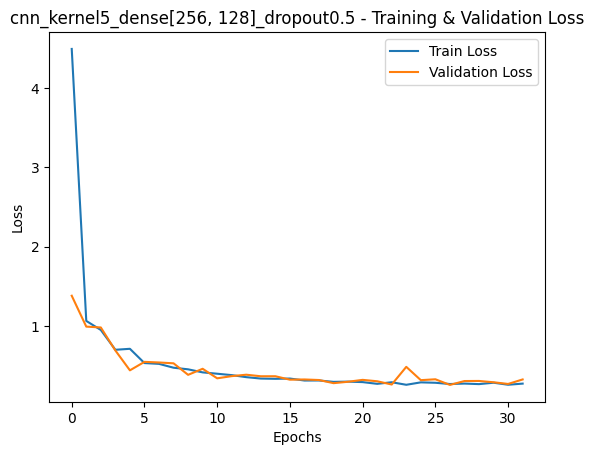

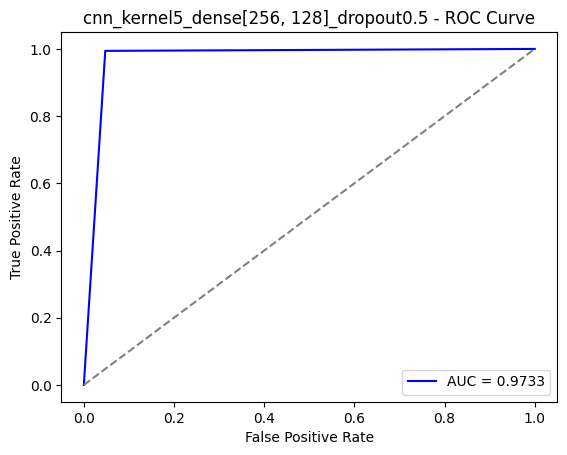

2025/03/01 19:46:59 INFO mlflow.tracking.fluent: Experiment with name 'cnn_kernel5_dense[256, 128]_dropout0.5 with LR 0.0005 and Batch 32' does not exist. Creating a new experiment.


Epoch 1/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - accuracy: 0.9870 - loss: 0.1921 - val_accuracy: 0.9751 - val_loss: 0.2506
Epoch 2/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9844 - loss: 0.2035 - val_accuracy: 0.9763 - val_loss: 0.2347
Epoch 3/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - accuracy: 0.9864 - loss: 0.1906 - val_accuracy: 0.9775 - val_loss: 0.2308
Epoch 4/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9849 - loss: 0.2012 - val_accuracy: 0.9763 - val_loss: 0.2642
Epoch 5/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.9866 - loss: 0.2042 - val_accuracy: 0.9482 - val_loss: 0.3522
Epoch 6/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.9838 - loss: 0.2284 - val_accuracy: 0.9761 - val_loss: 0.2418
Epoch 7/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.9862 - loss: 0.1932 - val_accuracy: 0.9688 - val_loss: 0.2729
Epoch 8/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.9835 - loss: 0.2155 - 

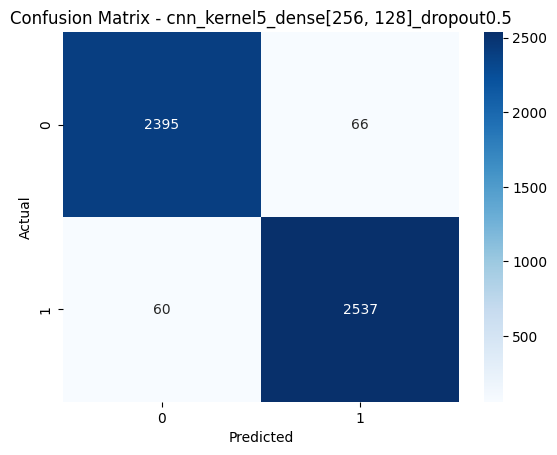

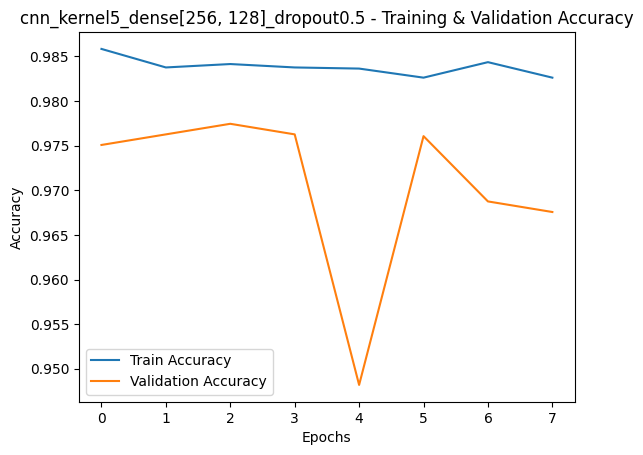

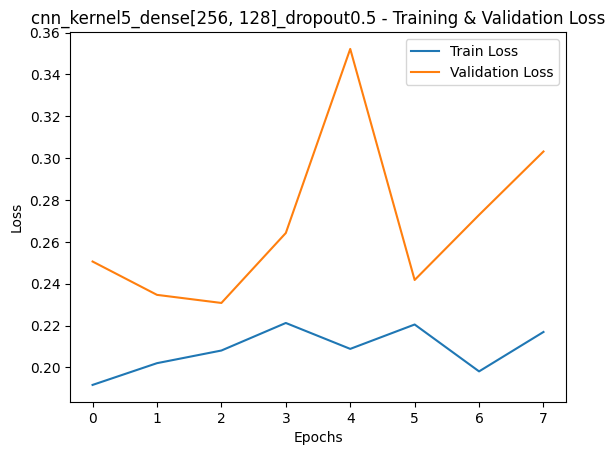

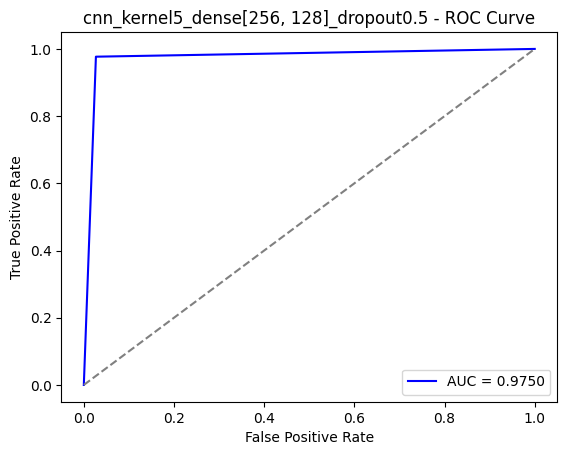

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)              │ ?                           │       1,709,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_4 (Conv1D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_4 (MaxPooling1D)       │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,709,400 (6.52 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,709,400 (6.52 MB)

2025/03/01 19:49:42 INFO mlflow.tracking.fluent: Experiment with name 'cnn_kernel5_dense[256, 128]_dropout0.5 with LR 0.0001 and Batch 16' does not exist. Creating a new experiment.


Epoch 1/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 32s 16ms/step - accuracy: 0.6783 - loss: 7.3136 - val_accuracy: 0.9557 - val_loss: 3.5747
Epoch 2/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - accuracy: 0.9493 - loss: 3.0001 - val_accuracy: 0.9666 - val_loss: 1.6266
Epoch 3/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.9750 - loss: 1.3732 - val_accuracy: 0.9725 - val_loss: 0.9275
Epoch 4/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.9796 - loss: 0.8011 - val_accuracy: 0.9761 - val_loss: 0.8119
Epoch 5/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.9852 - loss: 0.6545 - val_accuracy: 0.9585 - val_loss: 0.5992
Epoch 6/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - accuracy: 0.9844 - loss: 0.5429 - val_accuracy: 0.9779 - val_loss: 0.5153
Epoch 7/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.9894 - loss: 0.4273 - val_accuracy: 0.9715 - val_loss: 0.4794
Epoch 8/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.9888 -

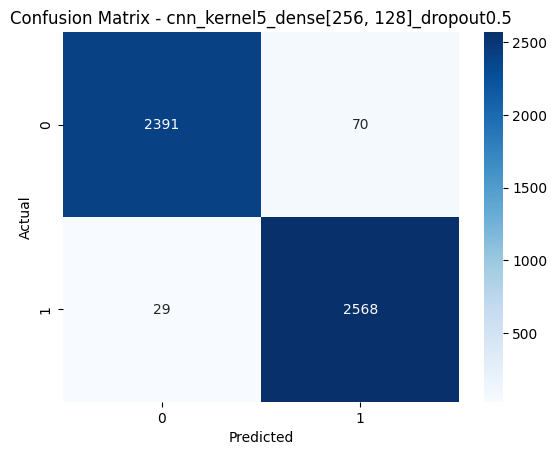

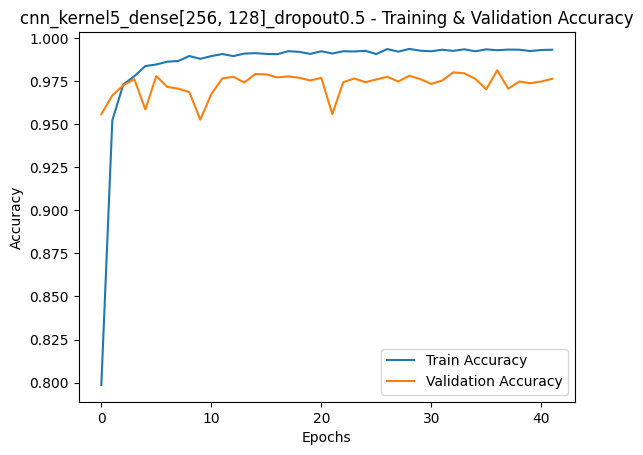

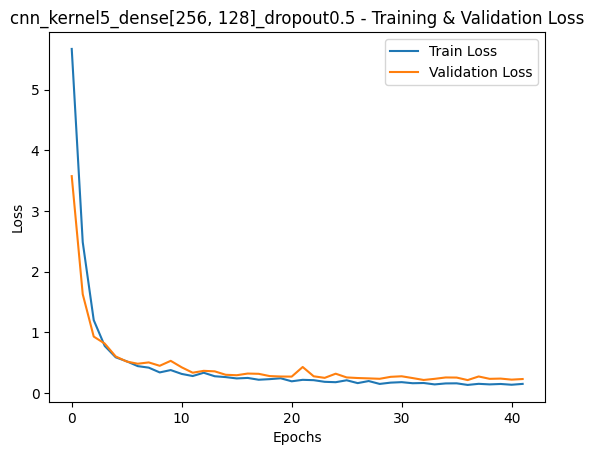

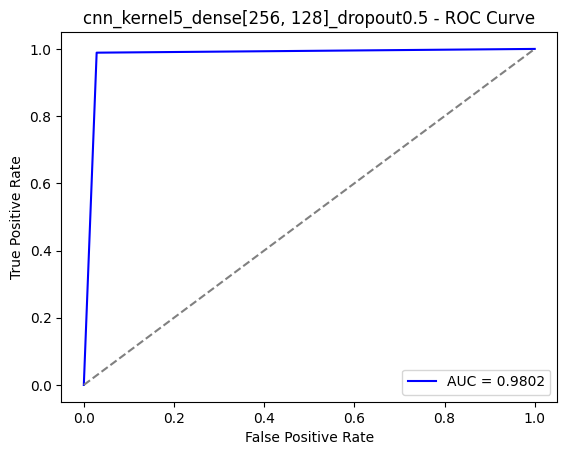

2025/03/01 20:05:20 INFO mlflow.tracking.fluent: Experiment with name 'cnn_kernel5_dense[256, 128]_dropout0.5 with LR 0.0001 and Batch 32' does not exist. Creating a new experiment.


Epoch 1/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.9968 - loss: 0.1236 - val_accuracy: 0.9804 - val_loss: 0.1700
Epoch 2/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9972 - loss: 0.0891 - val_accuracy: 0.9808 - val_loss: 0.1546
Epoch 3/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.9962 - loss: 0.0844 - val_accuracy: 0.9777 - val_loss: 0.1763
Epoch 4/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.9960 - loss: 0.0945 - val_accuracy: 0.9759 - val_loss: 0.1846
Epoch 5/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.9942 - loss: 0.1049 - val_accuracy: 0.9757 - val_loss: 0.1907
Epoch 6/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.9961 - loss: 0.1001 - val_accuracy: 0.9753 - val_loss: 0.2075
Epoch 7/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.9953 - loss: 0.1020 - val_accuracy: 0.9784 - val_loss: 0.1866
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
test_los

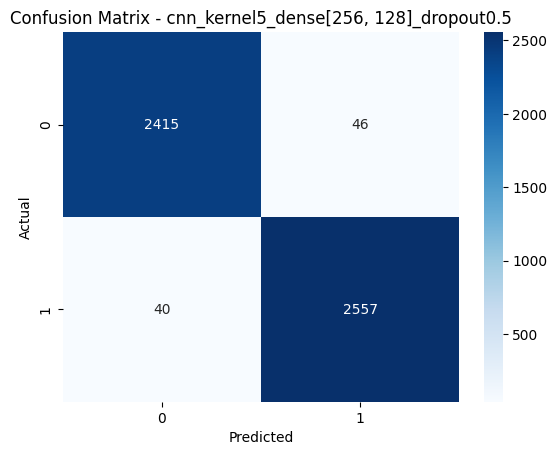

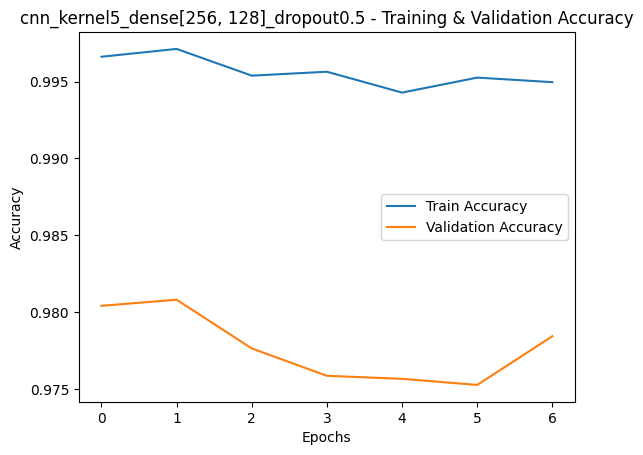

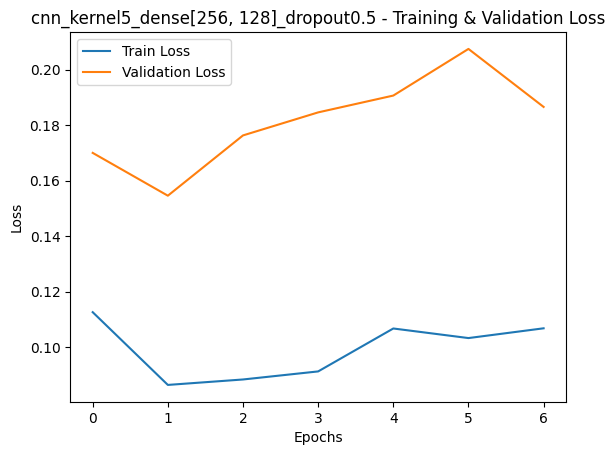

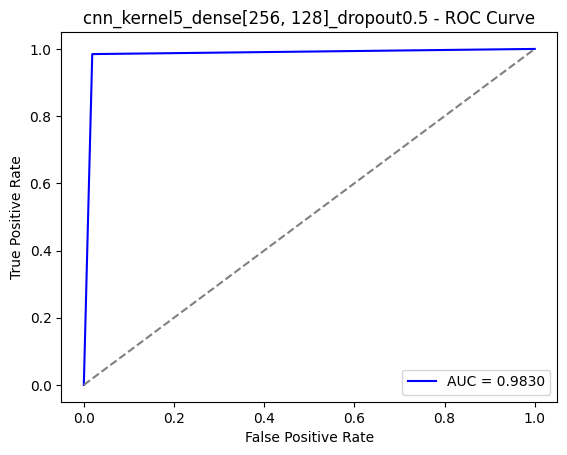

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)              │ ?                           │       1,709,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_5 (Conv1D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_5 (MaxPooling1D)       │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_5 (Flatten)                  │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,709,400 (6.52 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,709,400 (6.52 MB)

2025/03/01 20:07:33 INFO mlflow.tracking.fluent: Experiment with name 'cnn_kernel5_dense[128, 64]_dropout0.5 with LR 0.001 and Batch 16' does not exist. Creating a new experiment.


Epoch 1/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.7572 - loss: 5.0784 - val_accuracy: 0.9446 - val_loss: 0.9223
Epoch 2/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9348 - loss: 1.0842 - val_accuracy: 0.9203 - val_loss: 1.2929
Epoch 3/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9550 - loss: 0.8299 - val_accuracy: 0.9547 - val_loss: 0.6415
Epoch 4/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9518 - loss: 0.7022 - val_accuracy: 0.9660 - val_loss: 0.5123
Epoch 5/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9571 - loss: 0.5132 - val_accuracy: 0.9630 - val_loss: 0.4932
Epoch 6/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9580 - loss: 0.5032 - val_accuracy: 0.9610 - val_loss: 0.4011
Epoch 7/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9621 - loss: 0.4064 - val_accuracy: 0.9519 - val_loss: 0.4783
Epoch 8/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9599 - loss: 

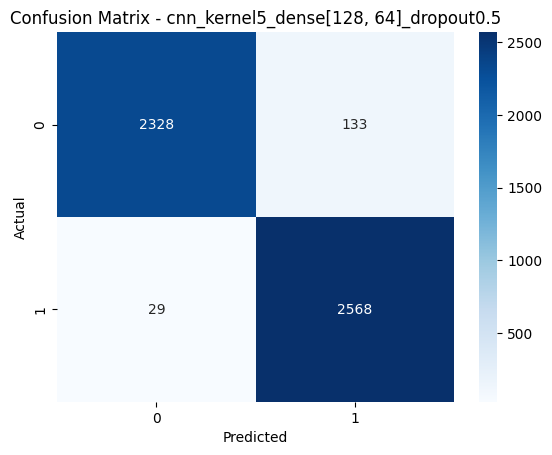

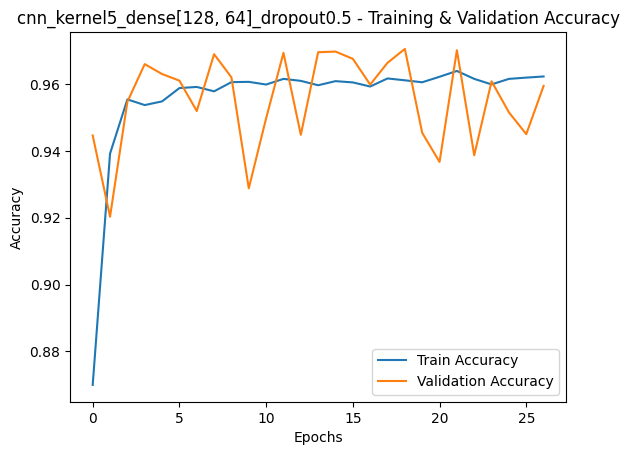

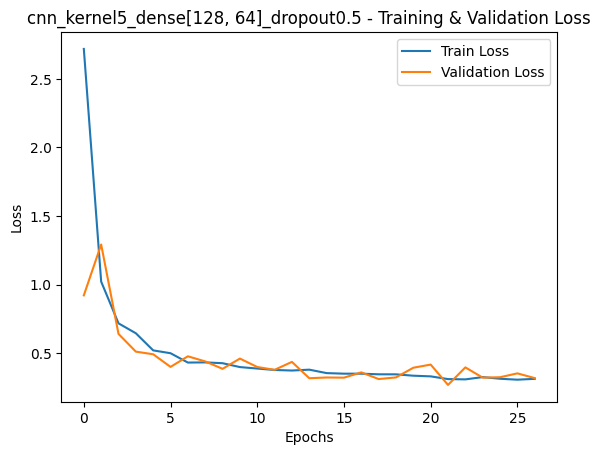

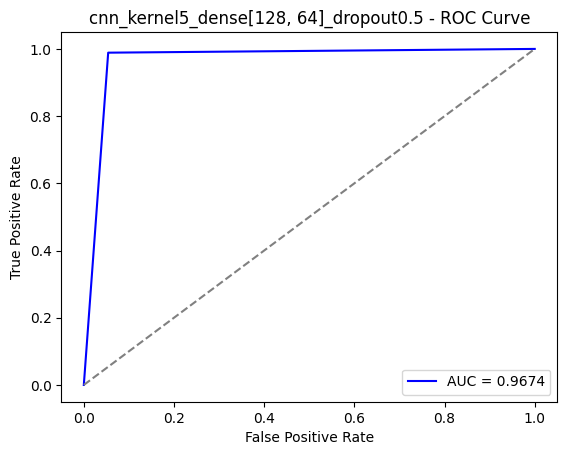

2025/03/01 20:14:34 INFO mlflow.tracking.fluent: Experiment with name 'cnn_kernel5_dense[128, 64]_dropout0.5 with LR 0.001 and Batch 32' does not exist. Creating a new experiment.


Epoch 1/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.9692 - loss: 0.2738 - val_accuracy: 0.9688 - val_loss: 0.2441
Epoch 2/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9753 - loss: 0.2215 - val_accuracy: 0.9699 - val_loss: 0.2407
Epoch 3/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9756 - loss: 0.2259 - val_accuracy: 0.9711 - val_loss: 0.2539
Epoch 4/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9709 - loss: 0.2483 - val_accuracy: 0.9656 - val_loss: 0.2633
Epoch 5/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9734 - loss: 0.2283 - val_accuracy: 0.9666 - val_loss: 0.2576
Epoch 6/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9699 - loss: 0.2508 - val_accuracy: 0.9686 - val_loss: 0.2689
Epoch 7/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9738 - loss: 0.2330 - val_accuracy: 0.9729 - val_loss: 0.2506
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
test_loss: 0.23

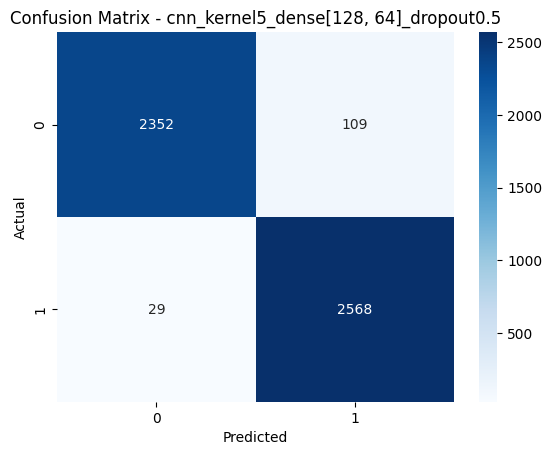

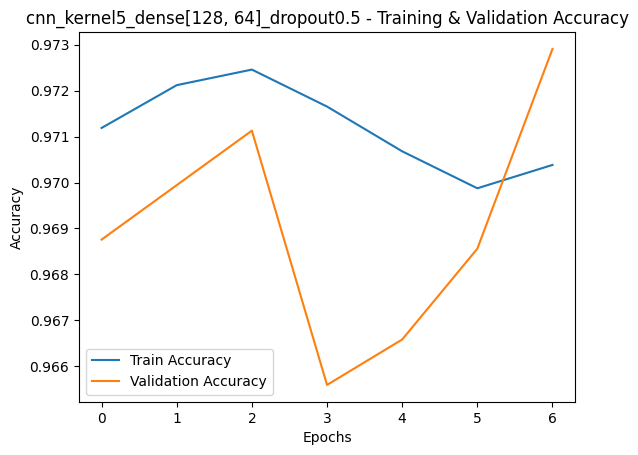

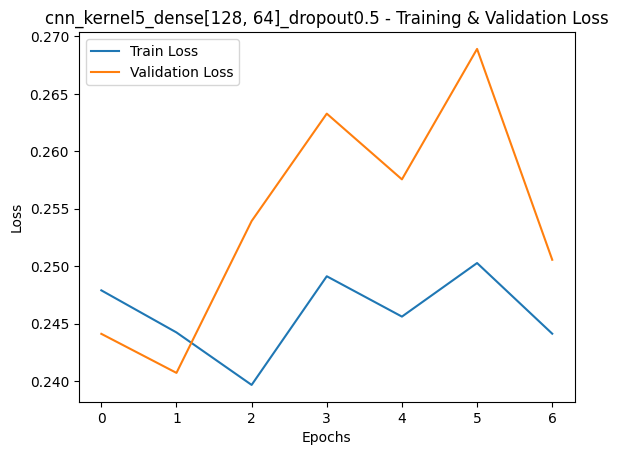

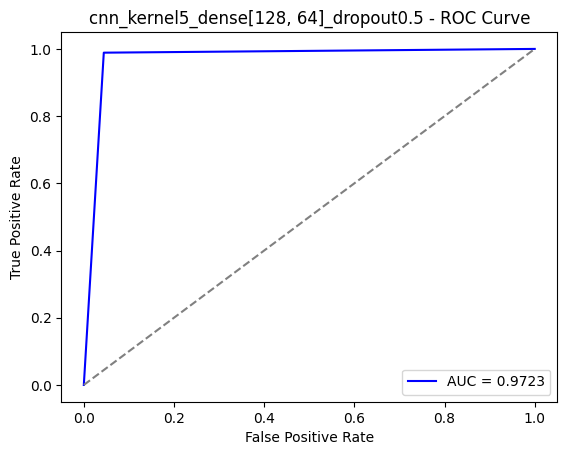

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)              │ ?                           │       1,709,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_6 (Conv1D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_6 (MaxPooling1D)       │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_6 (Flatten)                  │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,709,400 (6.52 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,709,400 (6.52 MB)

2025/03/01 20:15:45 INFO mlflow.tracking.fluent: Experiment with name 'cnn_kernel5_dense[128, 64]_dropout0.5 with LR 0.0005 and Batch 16' does not exist. Creating a new experiment.


Epoch 1/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.7660 - loss: 4.3730 - val_accuracy: 0.9419 - val_loss: 1.0715
Epoch 2/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9494 - loss: 0.9572 - val_accuracy: 0.9709 - val_loss: 0.6961
Epoch 3/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9617 - loss: 0.6855 - val_accuracy: 0.9703 - val_loss: 0.7732
Epoch 4/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9683 - loss: 0.6287 - val_accuracy: 0.9737 - val_loss: 0.5868
Epoch 5/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9741 - loss: 0.5062 - val_accuracy: 0.9573 - val_loss: 0.5493
Epoch 6/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9732 - loss: 0.4728 - val_accuracy: 0.9537 - val_loss: 0.5126
Epoch 7/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9731 - loss: 0.4230 - val_accuracy: 0.9674 - val_loss: 0.4713
Epoch 8/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9715 - loss: 

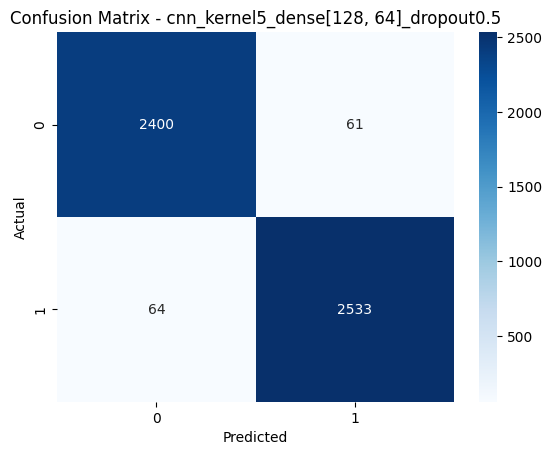

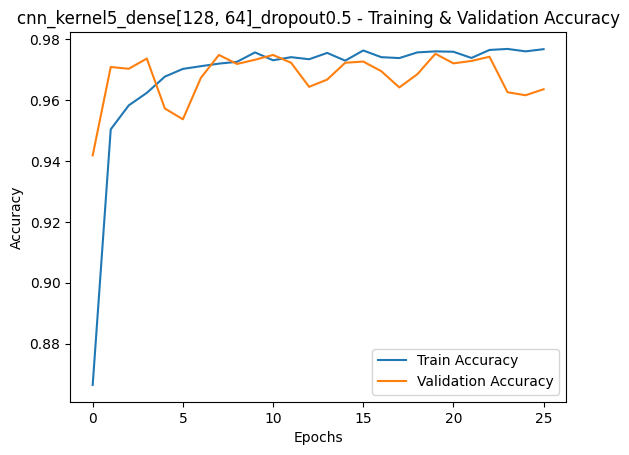

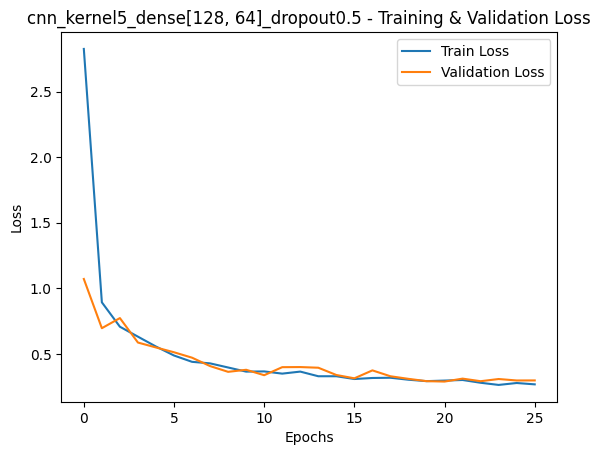

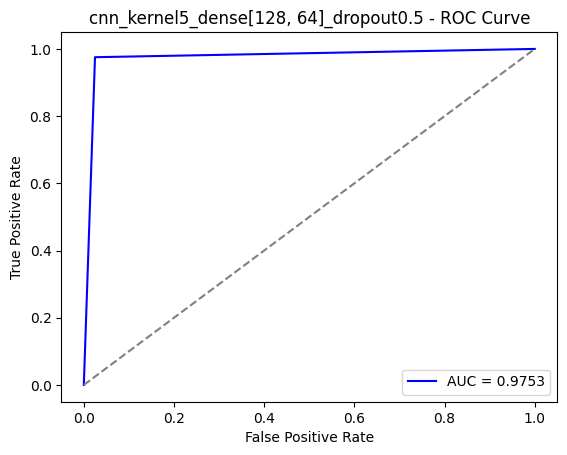

2025/03/01 20:22:37 INFO mlflow.tracking.fluent: Experiment with name 'cnn_kernel5_dense[128, 64]_dropout0.5 with LR 0.0005 and Batch 32' does not exist. Creating a new experiment.


Epoch 1/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.9814 - loss: 0.2341 - val_accuracy: 0.9755 - val_loss: 0.2246
Epoch 2/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9880 - loss: 0.1757 - val_accuracy: 0.9727 - val_loss: 0.2559
Epoch 3/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9835 - loss: 0.2118 - val_accuracy: 0.9782 - val_loss: 0.2411
Epoch 4/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9863 - loss: 0.1950 - val_accuracy: 0.9721 - val_loss: 0.2697
Epoch 5/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9871 - loss: 0.1954 - val_accuracy: 0.9751 - val_loss: 0.2573
Epoch 6/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9838 - loss: 0.2156 - val_accuracy: 0.9721 - val_loss: 0.2709
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
test_loss: 0.22118991613388062
test_accuracy: 0.9756820797920227
precision: 0.9598513011152416
recall: 0.9942241047362341
f1_score: 0.97673538868

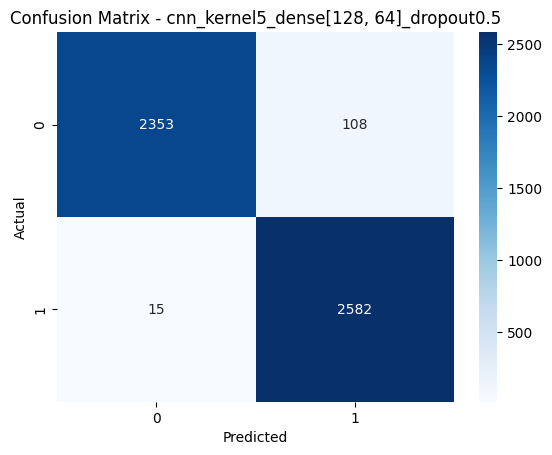

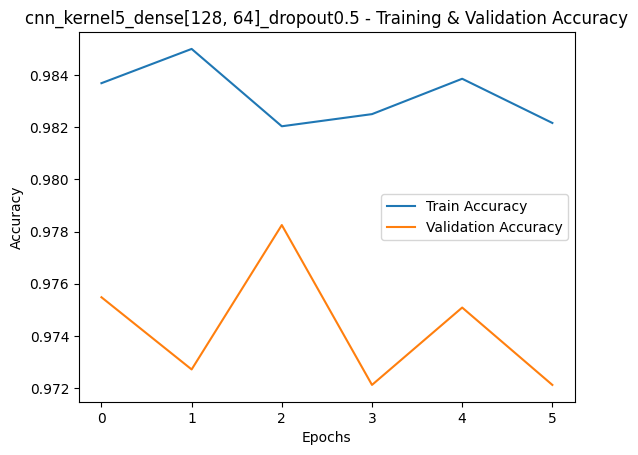

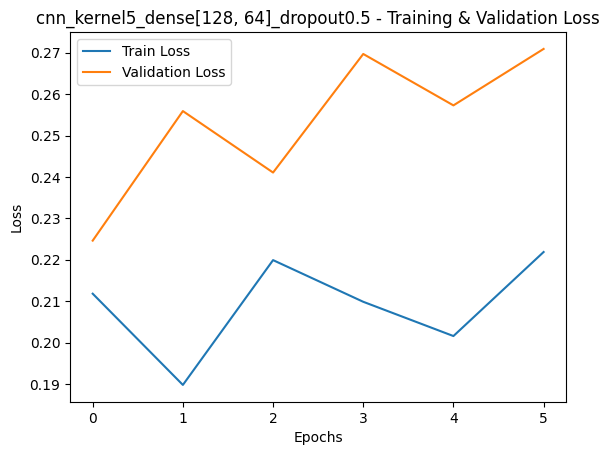

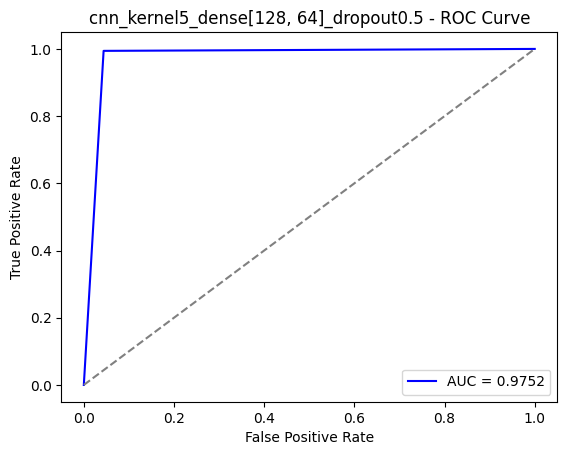

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)              │ ?                           │       1,709,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_7 (Conv1D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_7 (MaxPooling1D)       │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_7 (Flatten)                  │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_15 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,709,400 (6.52 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,709,400 (6.52 MB)

2025/03/01 20:23:39 INFO mlflow.tracking.fluent: Experiment with name 'cnn_kernel5_dense[128, 64]_dropout0.5 with LR 0.0001 and Batch 16' does not exist. Creating a new experiment.


Epoch 1/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.6218 - loss: 4.4169 - val_accuracy: 0.9334 - val_loss: 2.3035
Epoch 2/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.9229 - loss: 2.0306 - val_accuracy: 0.9606 - val_loss: 1.2380
Epoch 3/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9616 - loss: 1.1023 - val_accuracy: 0.9569 - val_loss: 0.8357
Epoch 4/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9749 - loss: 0.7069 - val_accuracy: 0.9715 - val_loss: 0.5808
Epoch 5/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9817 - loss: 0.5221 - val_accuracy: 0.9727 - val_loss: 0.4877
Epoch 6/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9839 - loss: 0.4415 - val_accuracy: 0.9755 - val_loss: 0.4438
Epoch 7/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9874 - loss: 0.3823 - val_accuracy: 0.9749 - val_loss: 0.4069
Epoch 8/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9890 - loss: 

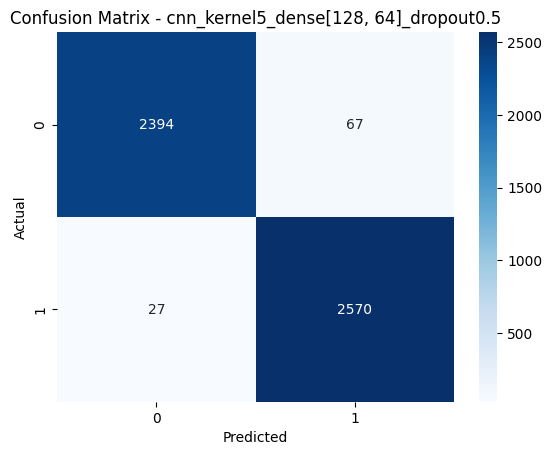

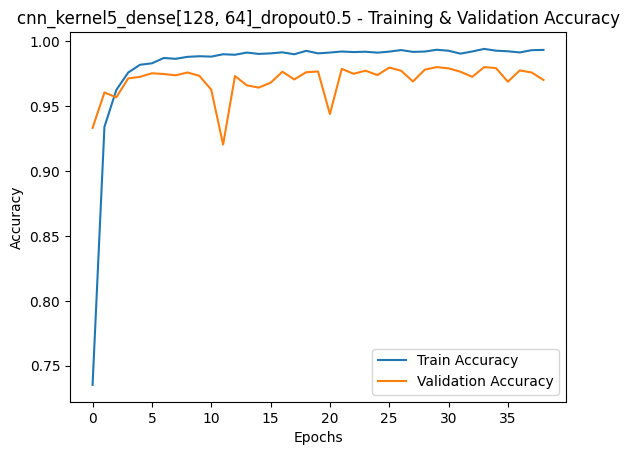

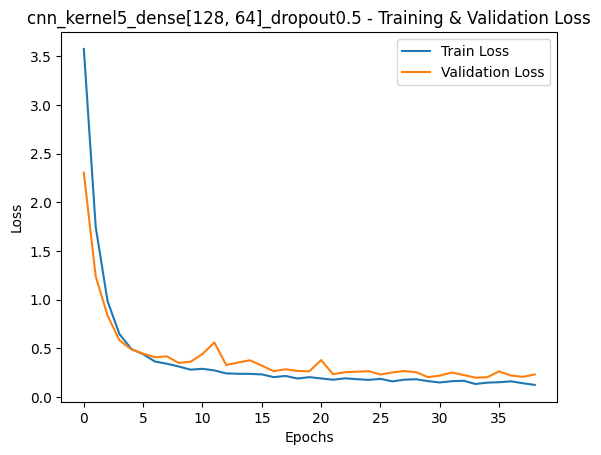

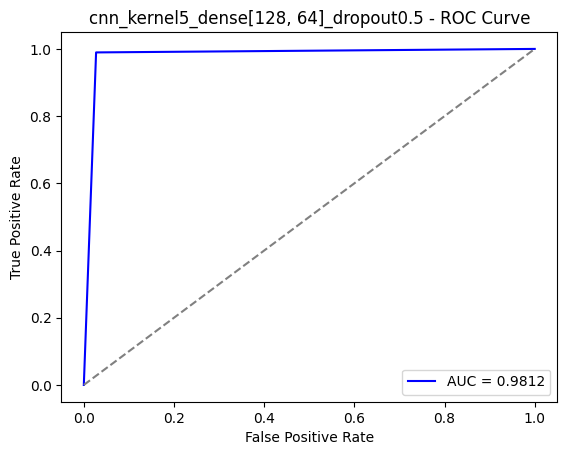

2025/03/01 20:34:16 INFO mlflow.tracking.fluent: Experiment with name 'cnn_kernel5_dense[128, 64]_dropout0.5 with LR 0.0001 and Batch 32' does not exist. Creating a new experiment.


Epoch 1/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.9960 - loss: 0.1188 - val_accuracy: 0.9788 - val_loss: 0.1855
Epoch 2/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9962 - loss: 0.1107 - val_accuracy: 0.9796 - val_loss: 0.1699
Epoch 3/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9972 - loss: 0.0882 - val_accuracy: 0.9775 - val_loss: 0.1664
Epoch 4/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9950 - loss: 0.0950 - val_accuracy: 0.9798 - val_loss: 0.1689
Epoch 5/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9948 - loss: 0.1061 - val_accuracy: 0.9771 - val_loss: 0.2012
Epoch 6/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9956 - loss: 0.1129 - val_accuracy: 0.9763 - val_loss: 0.1834
Epoch 7/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9951 - loss: 0.1058 - val_accuracy: 0.9771 - val_loss: 0.1823
Epoch 8/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9955 - loss: 0.1058 - val_ac

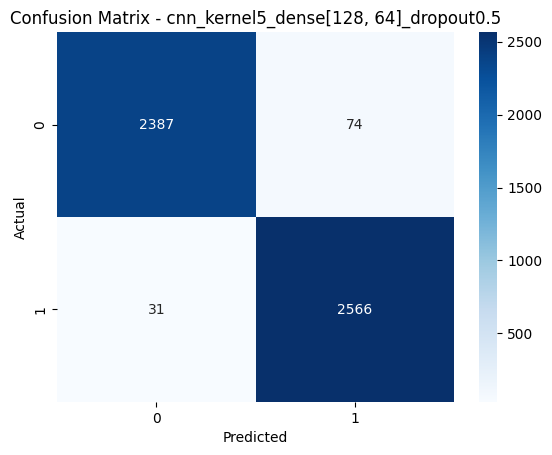

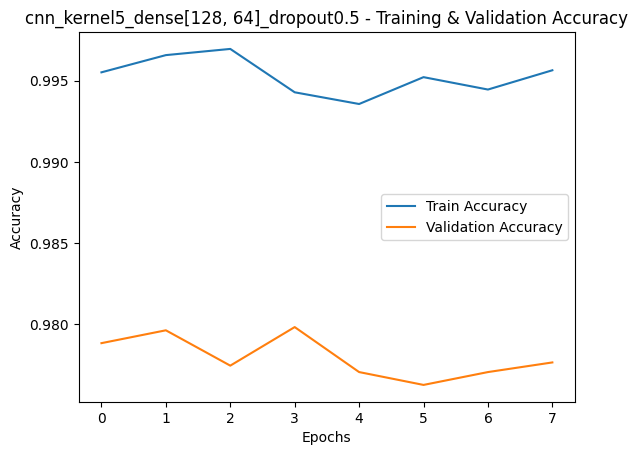

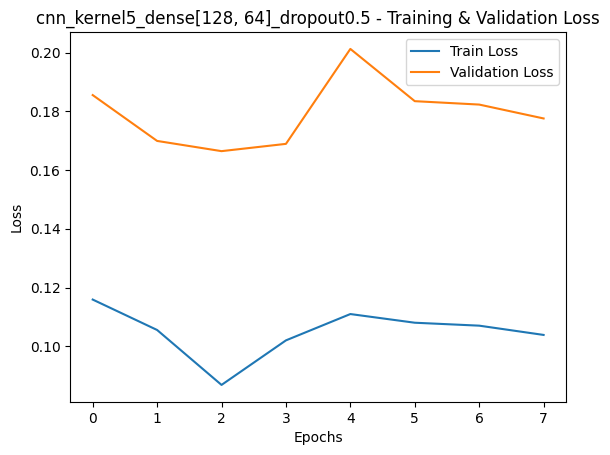

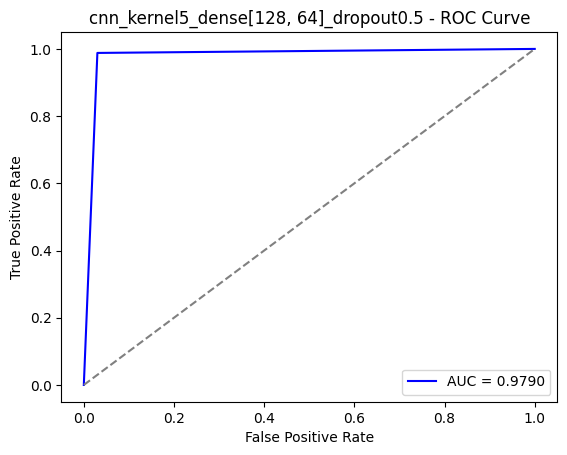

In [ ]:
# CNN Model Training
for kernel in KERNEL_SIZE:
  for dense in DENSE:
    for dropout in DROPOUT_RATE:
      for lr in LEARNING_RATES:
        cnn_model =  build_cnn(vocab_size=len(word_index) + 1,
                              embedding_matrix=embedding_matrix,
                              kernel_size = kernel,
                              filters=dense[0],
                              dense_units=dense,
                              dropout_rate=dropout,
                              learning_rate=lr)
        model_name = f"cnn_kernel{kernel}_dense{dense}_dropout{dropout}"
        train_and_evaluate(cnn_model, model_name, lr, X_train_padded, y_train,
                            X_val_padded, y_val, X_test_padded, y_test)

### CNN + LSTM

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)              │ ?                           │       1,709,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_8 (Conv1D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_8 (MaxPooling1D)       │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_16 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_17 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,709,400 (6.52 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,709,400 (6.52 MB)

2025/03/01 20:35:36 INFO mlflow.tracking.fluent: Experiment with name 'cnn_lstm_kernel5_dense[256, 128]_dropout0.5 with LR 0.001 and Batch 16' does not exist. Creating a new experiment.


Epoch 1/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 69s 40ms/step - accuracy: 0.8798 - loss: 0.2749 - val_accuracy: 0.9654 - val_loss: 0.1019
Epoch 2/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 77s 40ms/step - accuracy: 0.9708 - loss: 0.0895 - val_accuracy: 0.9769 - val_loss: 0.0674
Epoch 3/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 82s 40ms/step - accuracy: 0.9784 - loss: 0.0621 - val_accuracy: 0.9784 - val_loss: 0.0633
Epoch 4/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 83s 40ms/step - accuracy: 0.9856 - loss: 0.0446 - val_accuracy: 0.9705 - val_loss: 0.0906
Epoch 5/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 81s 40ms/step - accuracy: 0.9871 - loss: 0.0386 - val_accuracy: 0.9808 - val_loss: 0.0595
Epoch 6/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 82s 40ms/step - accuracy: 0.9907 - loss: 0.0306 - val_accuracy: 0.9814 - val_loss: 0.0595
Epoch 7/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 58s 39ms/step - accuracy: 0.9911 - loss: 0.0259 - val_accuracy: 0.9820 - val_loss: 0.0616
Epoch 8/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 58s 40ms/step - accuracy: 0.9903 -

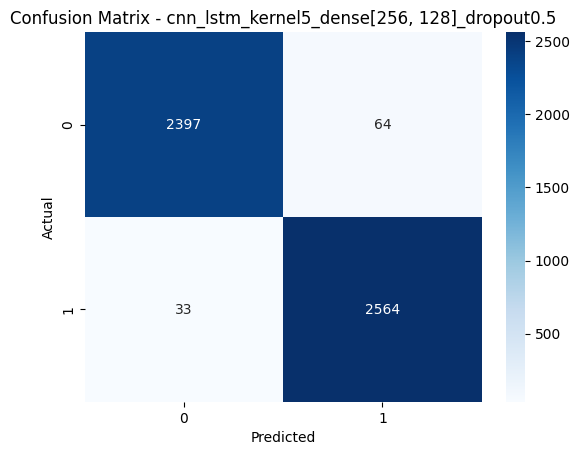

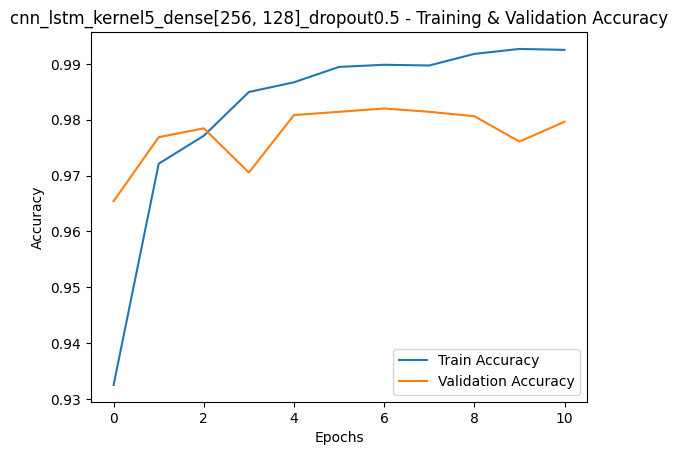

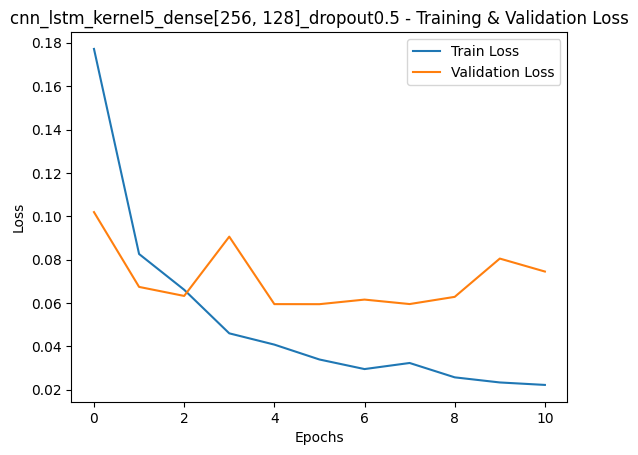

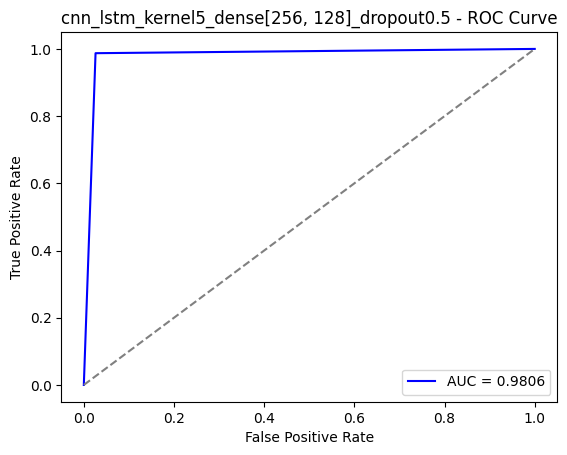

2025/03/01 20:50:09 INFO mlflow.tracking.fluent: Experiment with name 'cnn_lstm_kernel5_dense[256, 128]_dropout0.5 with LR 0.001 and Batch 32' does not exist. Creating a new experiment.


Epoch 1/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 36s 49ms/step - accuracy: 0.9943 - loss: 0.0190 - val_accuracy: 0.9844 - val_loss: 0.0635
Epoch 2/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - accuracy: 0.9953 - loss: 0.0134 - val_accuracy: 0.9822 - val_loss: 0.0716
Epoch 3/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 33s 44ms/step - accuracy: 0.9957 - loss: 0.0128 - val_accuracy: 0.9822 - val_loss: 0.0758
Epoch 4/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 33s 44ms/step - accuracy: 0.9947 - loss: 0.0176 - val_accuracy: 0.9810 - val_loss: 0.0779
Epoch 5/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 32s 44ms/step - accuracy: 0.9952 - loss: 0.0160 - val_accuracy: 0.9826 - val_loss: 0.0794
Epoch 6/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 41s 44ms/step - accuracy: 0.9960 - loss: 0.0113 - val_accuracy: 0.9810 - val_loss: 0.1070
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step
test_loss: 0.06213674694299698
test_accuracy: 0.9845789074897766
precision: 0.9776260902540767
recall: 0.9926838659992299
f1_score: 0.98

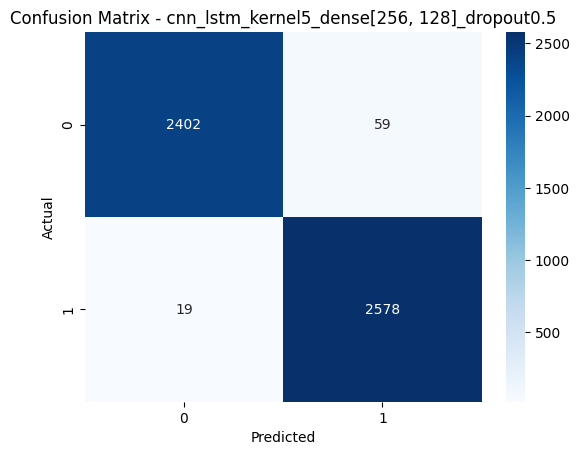

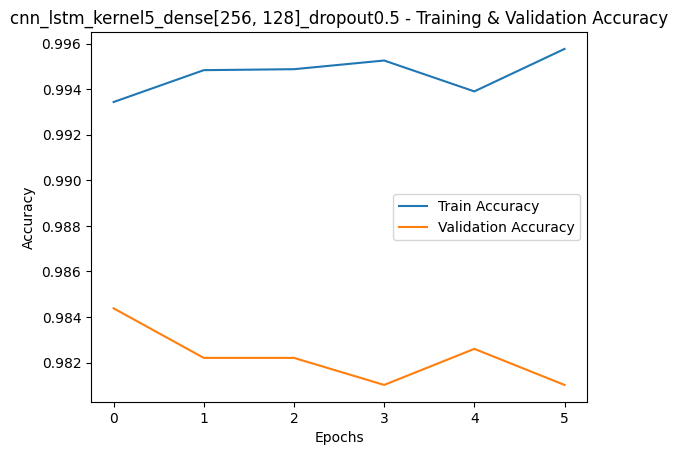

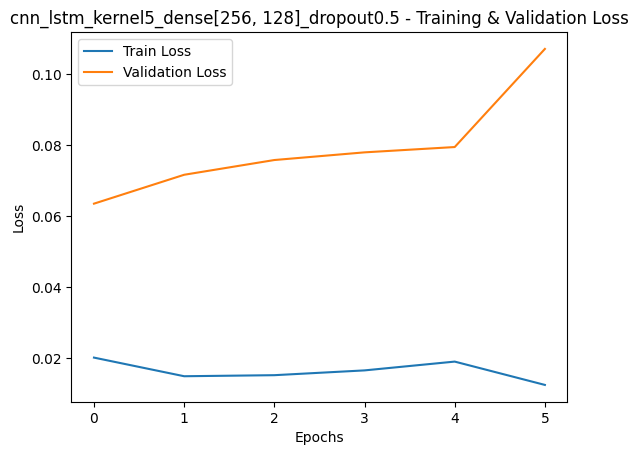

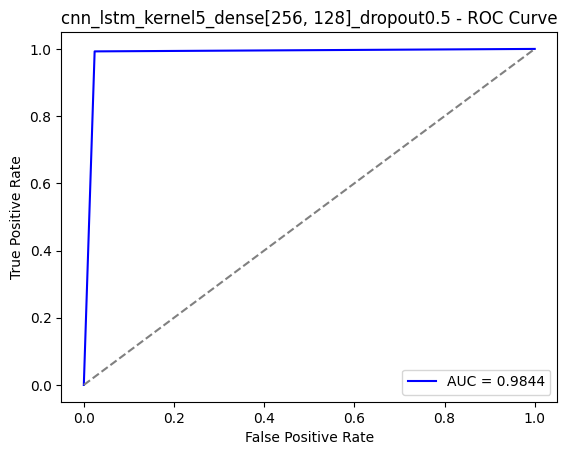

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)              │ ?                           │       1,709,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_9 (Conv1D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_9 (MaxPooling1D)       │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_27 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_18 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_28 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_19 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_29 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,709,400 (6.52 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,709,400 (6.52 MB)

2025/03/01 20:53:58 INFO mlflow.tracking.fluent: Experiment with name 'cnn_lstm_kernel5_dense[256, 128]_dropout0.5 with LR 0.0005 and Batch 16' does not exist. Creating a new experiment.


Epoch 1/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 65s 41ms/step - accuracy: 0.8783 - loss: 0.2717 - val_accuracy: 0.9743 - val_loss: 0.0738
Epoch 2/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 59s 40ms/step - accuracy: 0.9751 - loss: 0.0740 - val_accuracy: 0.9697 - val_loss: 0.0843
Epoch 3/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 82s 40ms/step - accuracy: 0.9838 - loss: 0.0467 - val_accuracy: 0.9618 - val_loss: 0.1137
Epoch 4/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 60s 41ms/step - accuracy: 0.9863 - loss: 0.0420 - val_accuracy: 0.9836 - val_loss: 0.0506
Epoch 5/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 82s 41ms/step - accuracy: 0.9903 - loss: 0.0257 - val_accuracy: 0.9721 - val_loss: 0.0841
Epoch 6/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 82s 41ms/step - accuracy: 0.9914 - loss: 0.0227 - val_accuracy: 0.9794 - val_loss: 0.0786
Epoch 7/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 60s 41ms/step - accuracy: 0.9924 - loss: 0.0231 - val_accuracy: 0.9828 - val_loss: 0.0629
Epoch 8/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 83s 41ms/step - accuracy: 0.9947 -

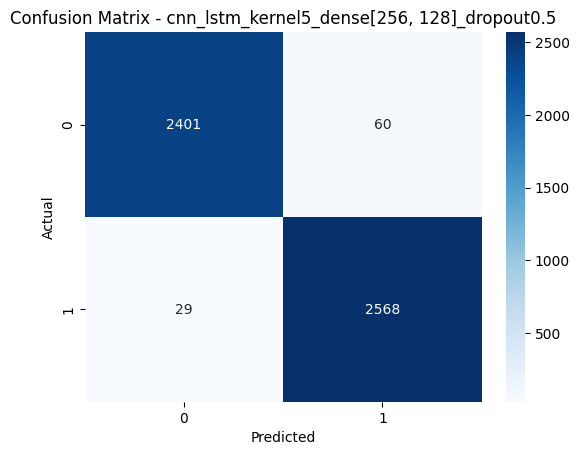

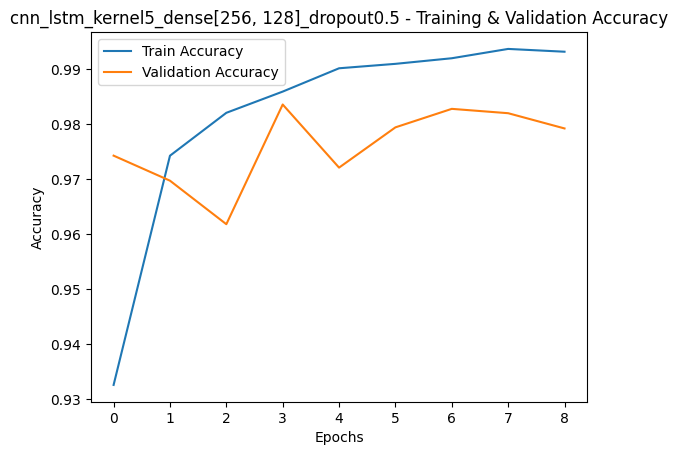

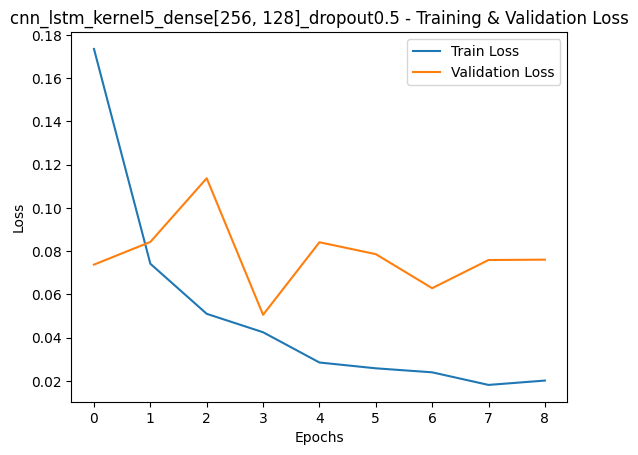

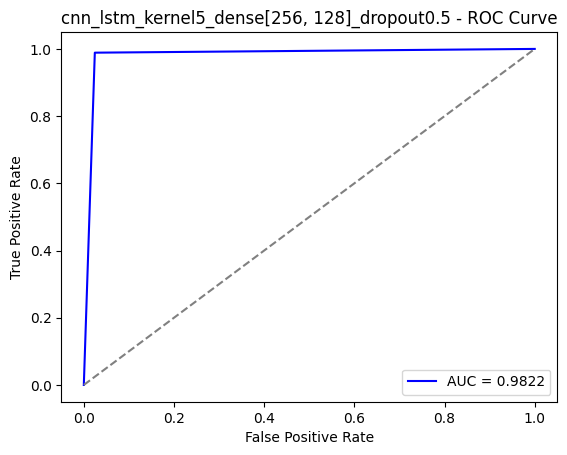

2025/03/01 21:05:11 INFO mlflow.tracking.fluent: Experiment with name 'cnn_lstm_kernel5_dense[256, 128]_dropout0.5 with LR 0.0005 and Batch 32' does not exist. Creating a new experiment.


Epoch 1/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 33s 45ms/step - accuracy: 0.9911 - loss: 0.0238 - val_accuracy: 0.9832 - val_loss: 0.0628
Epoch 2/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 40s 44ms/step - accuracy: 0.9963 - loss: 0.0121 - val_accuracy: 0.9824 - val_loss: 0.0740
Epoch 3/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 33s 44ms/step - accuracy: 0.9941 - loss: 0.0178 - val_accuracy: 0.9771 - val_loss: 0.1139
Epoch 4/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 36s 48ms/step - accuracy: 0.9946 - loss: 0.0172 - val_accuracy: 0.9822 - val_loss: 0.0648
Epoch 5/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 33s 44ms/step - accuracy: 0.9963 - loss: 0.0123 - val_accuracy: 0.9850 - val_loss: 0.0744
Epoch 6/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 41s 45ms/step - accuracy: 0.9964 - loss: 0.0109 - val_accuracy: 0.9790 - val_loss: 0.0784
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step
159/159 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step
test_loss: 0.061386700719594955
test_accuracy: 0.9839857816696167
precision: 0.9761544284632854
recall: 0.9930689256834809
f1_score: 0.9

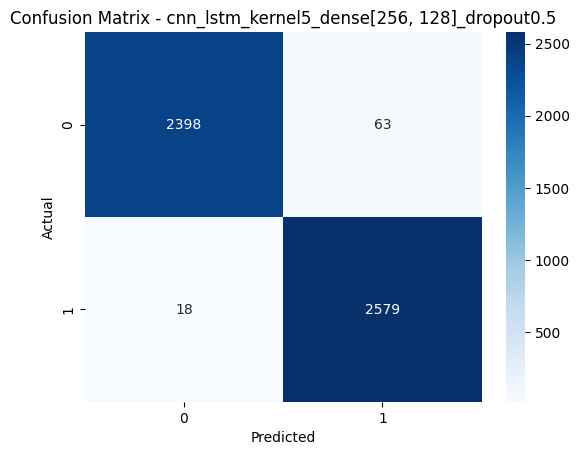

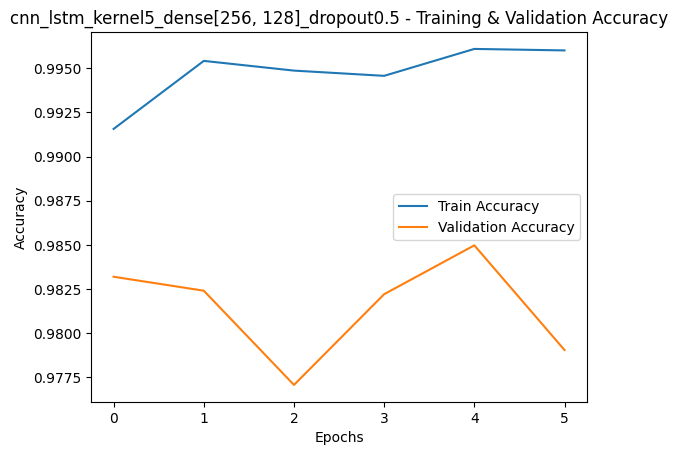

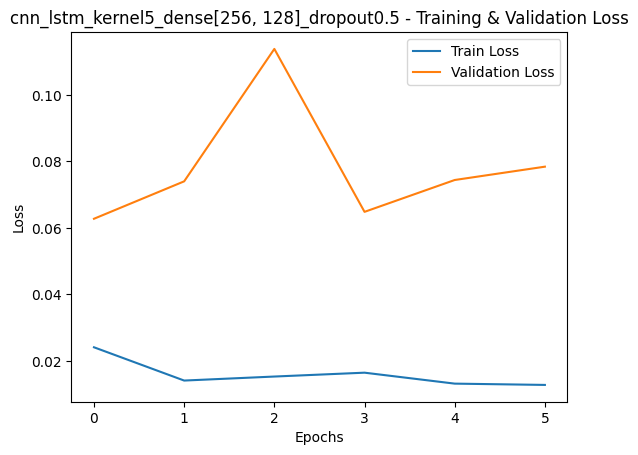

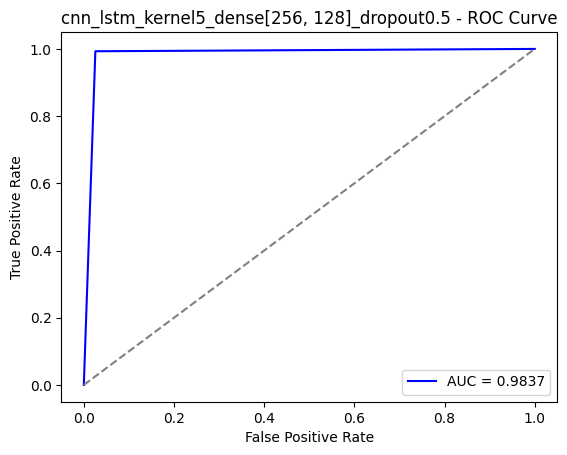

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)             │ ?                           │       1,709,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_10 (Conv1D)                   │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_10 (MaxPooling1D)      │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_2 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_30 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_20 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_31 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_21 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_32 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,709,400 (6.52 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,709,400 (6.52 MB)

2025/03/01 21:08:58 INFO mlflow.tracking.fluent: Experiment with name 'cnn_lstm_kernel5_dense[256, 128]_dropout0.5 with LR 0.0001 and Batch 16' does not exist. Creating a new experiment.


Epoch 1/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 65s 41ms/step - accuracy: 0.8164 - loss: 0.3746 - val_accuracy: 0.9686 - val_loss: 0.0901
Epoch 2/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 61s 41ms/step - accuracy: 0.9707 - loss: 0.0889 - val_accuracy: 0.9763 - val_loss: 0.0682
Epoch 3/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 82s 42ms/step - accuracy: 0.9835 - loss: 0.0495 - val_accuracy: 0.9784 - val_loss: 0.0590
Epoch 4/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 82s 41ms/step - accuracy: 0.9907 - loss: 0.0303 - val_accuracy: 0.9595 - val_loss: 0.1383
Epoch 5/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 60s 41ms/step - accuracy: 0.9924 - loss: 0.0223 - val_accuracy: 0.9482 - val_loss: 0.1839
Epoch 6/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 84s 42ms/step - accuracy: 0.9940 - loss: 0.0193 - val_accuracy: 0.9818 - val_loss: 0.0670
Epoch 7/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 60s 41ms/step - accuracy: 0.9941 - loss: 0.0193 - val_accuracy: 0.9814 - val_loss: 0.0708
Epoch 8/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 83s 42ms/step - accuracy: 0.9958 -

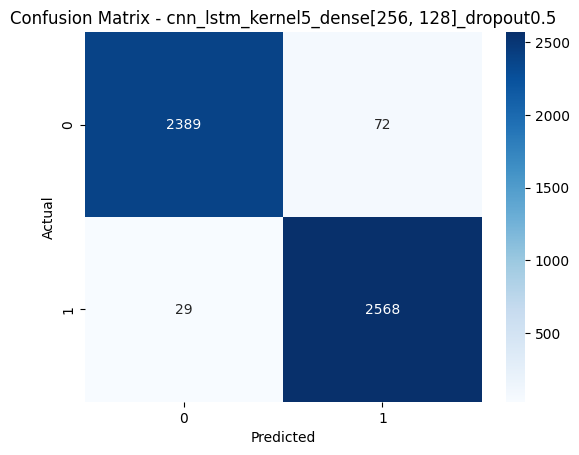

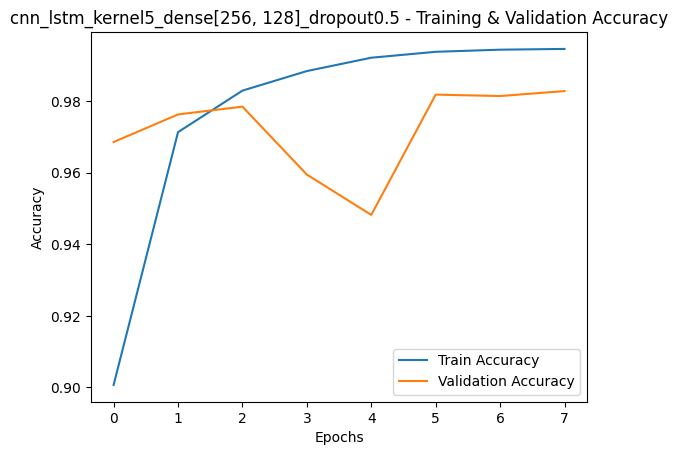

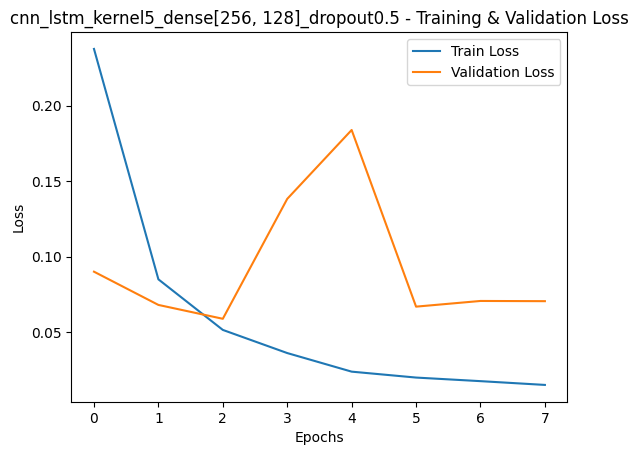

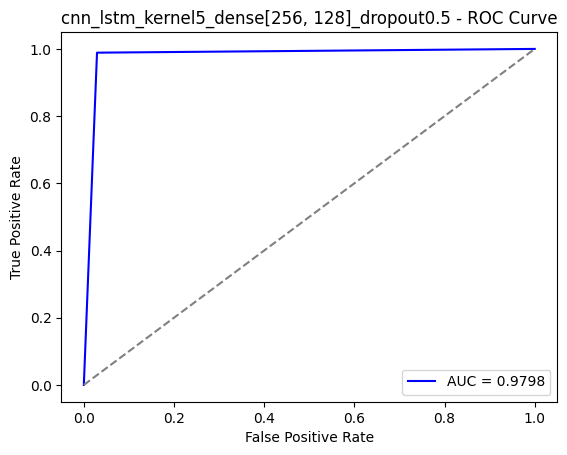

2025/03/01 21:19:06 INFO mlflow.tracking.fluent: Experiment with name 'cnn_lstm_kernel5_dense[256, 128]_dropout0.5 with LR 0.0001 and Batch 32' does not exist. Creating a new experiment.


Epoch 1/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 34s 46ms/step - accuracy: 0.9921 - loss: 0.0262 - val_accuracy: 0.9745 - val_loss: 0.0783
Epoch 2/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 40s 46ms/step - accuracy: 0.9947 - loss: 0.0176 - val_accuracy: 0.9735 - val_loss: 0.1045
Epoch 3/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 43s 49ms/step - accuracy: 0.9965 - loss: 0.0119 - val_accuracy: 0.9814 - val_loss: 0.0775
Epoch 4/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 38s 45ms/step - accuracy: 0.9969 - loss: 0.0101 - val_accuracy: 0.9567 - val_loss: 0.1763
Epoch 5/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 33s 45ms/step - accuracy: 0.9960 - loss: 0.0125 - val_accuracy: 0.9806 - val_loss: 0.0814
Epoch 6/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 44s 49ms/step - accuracy: 0.9968 - loss: 0.0110 - val_accuracy: 0.9842 - val_loss: 0.0711
Epoch 7/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 38s 46ms/step - accuracy: 0.9982 - loss: 0.0064 - val_accuracy: 0.9832 - val_loss: 0.0858
Epoch 8/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 41s 45ms/step - accuracy: 0.9972 - loss: 0.0103 - 

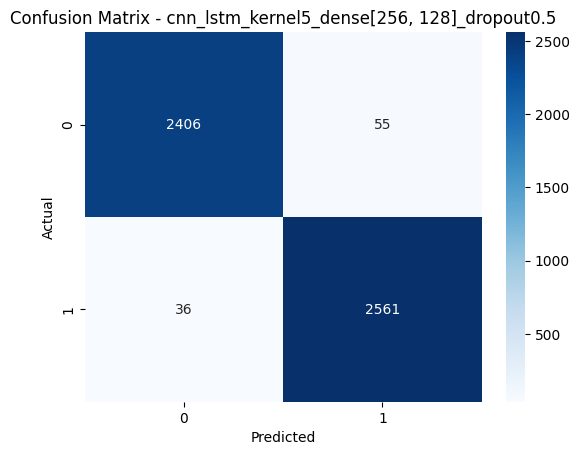

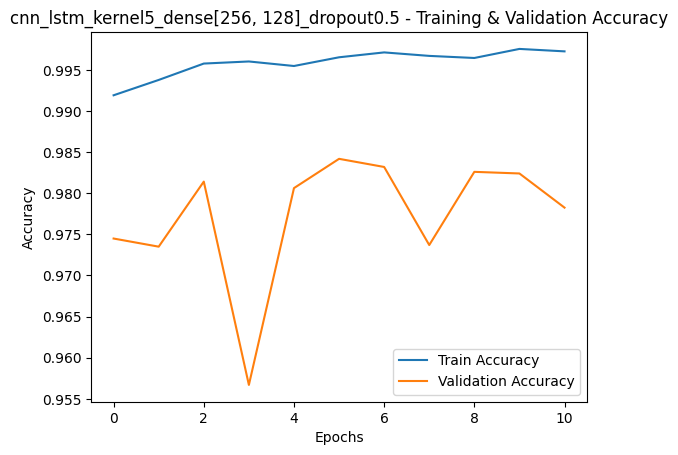

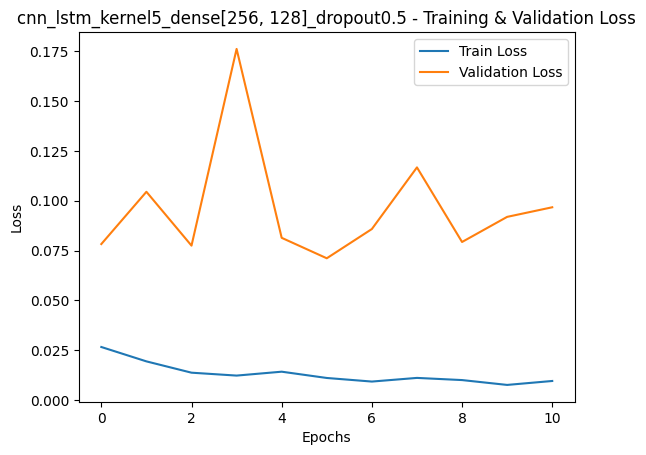

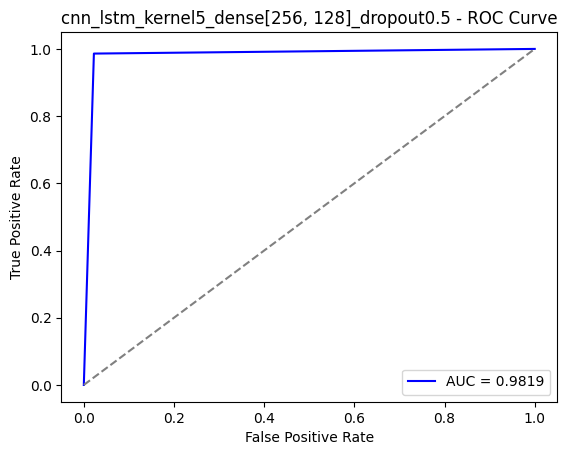

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)             │ ?                           │       1,709,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_11 (Conv1D)                   │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_11 (MaxPooling1D)      │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_3 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_33 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_22 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_34 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_23 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_35 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,709,400 (6.52 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,709,400 (6.52 MB)

2025/03/01 21:26:18 INFO mlflow.tracking.fluent: Experiment with name 'cnn_lstm_kernel5_dense[128, 64]_dropout0.5 with LR 0.001 and Batch 16' does not exist. Creating a new experiment.


Epoch 1/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 62s 39ms/step - accuracy: 0.8572 - loss: 0.3133 - val_accuracy: 0.9719 - val_loss: 0.0777
Epoch 2/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 82s 40ms/step - accuracy: 0.9712 - loss: 0.0859 - val_accuracy: 0.9739 - val_loss: 0.0732
Epoch 3/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 56s 38ms/step - accuracy: 0.9835 - loss: 0.0505 - val_accuracy: 0.9357 - val_loss: 0.1730
Epoch 4/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 82s 38ms/step - accuracy: 0.9849 - loss: 0.0452 - val_accuracy: 0.9749 - val_loss: 0.0724
Epoch 5/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 56s 38ms/step - accuracy: 0.9884 - loss: 0.0379 - val_accuracy: 0.9800 - val_loss: 0.0806
Epoch 6/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 84s 39ms/step - accuracy: 0.9901 - loss: 0.0270 - val_accuracy: 0.9806 - val_loss: 0.0636
Epoch 7/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 56s 38ms/step - accuracy: 0.9901 - loss: 0.0324 - val_accuracy: 0.9788 - val_loss: 0.0814
Epoch 8/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 56s 38ms/step - accuracy: 0.9930 -

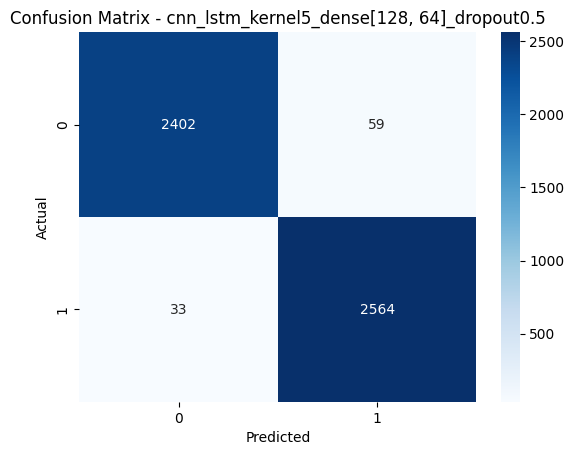

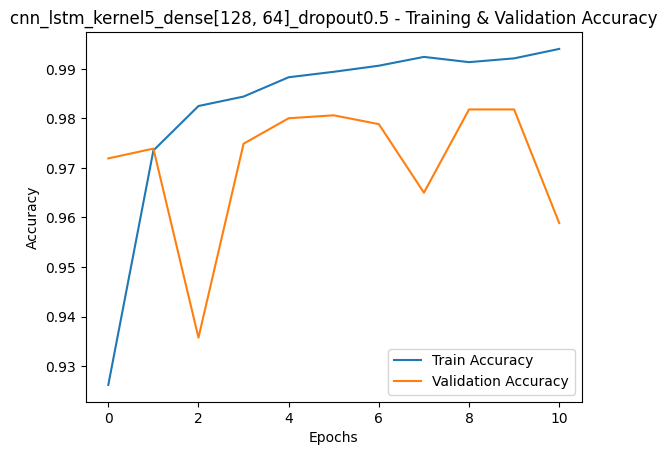

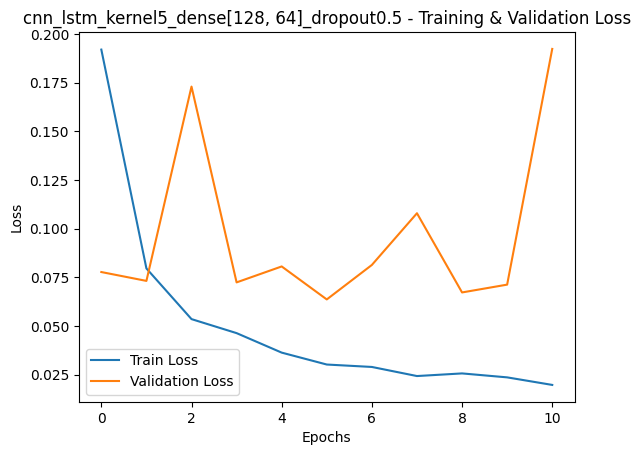

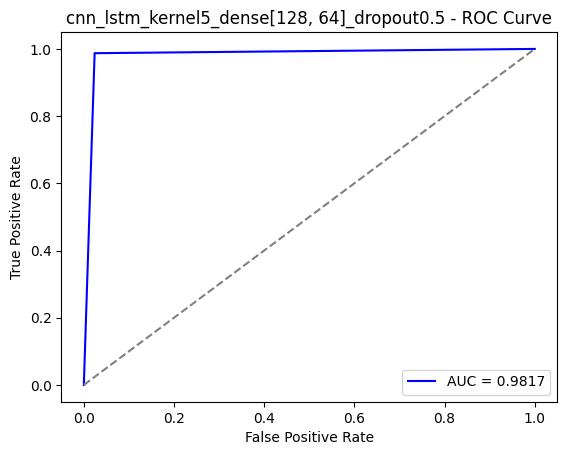

2025/03/01 21:39:38 INFO mlflow.tracking.fluent: Experiment with name 'cnn_lstm_kernel5_dense[128, 64]_dropout0.5 with LR 0.001 and Batch 32' does not exist. Creating a new experiment.


Epoch 1/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 30s 41ms/step - accuracy: 0.9926 - loss: 0.0233 - val_accuracy: 0.9816 - val_loss: 0.0757
Epoch 2/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 29s 40ms/step - accuracy: 0.9960 - loss: 0.0131 - val_accuracy: 0.9810 - val_loss: 0.0765
Epoch 3/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 41s 39ms/step - accuracy: 0.9955 - loss: 0.0140 - val_accuracy: 0.9830 - val_loss: 0.0726
Epoch 4/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 42s 40ms/step - accuracy: 0.9965 - loss: 0.0117 - val_accuracy: 0.9818 - val_loss: 0.0863
Epoch 5/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 40s 39ms/step - accuracy: 0.9965 - loss: 0.0108 - val_accuracy: 0.9830 - val_loss: 0.0725
Epoch 6/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 41s 39ms/step - accuracy: 0.9952 - loss: 0.0147 - val_accuracy: 0.9808 - val_loss: 0.0932
Epoch 7/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 41s 39ms/step - accuracy: 0.9970 - loss: 0.0110 - val_accuracy: 0.9818 - val_loss: 0.0996
Epoch 8/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 41s 39ms/step - accuracy: 0.9949 - loss: 0.0164 - 

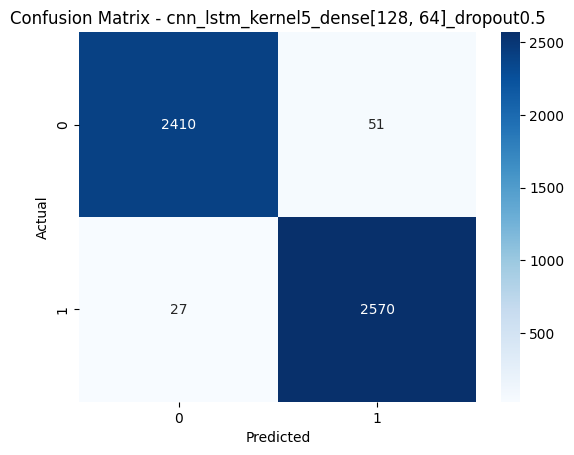

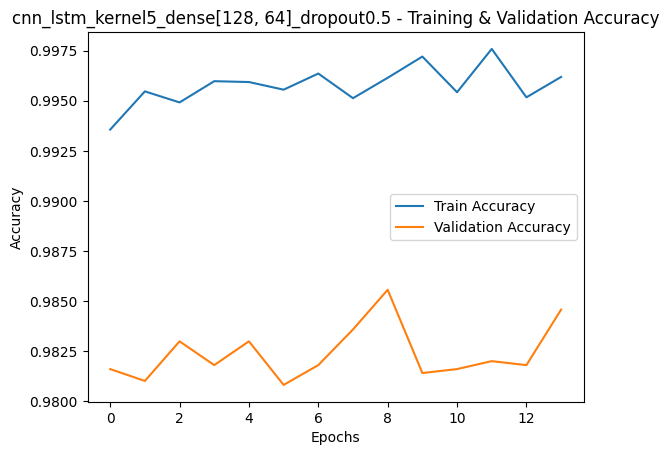

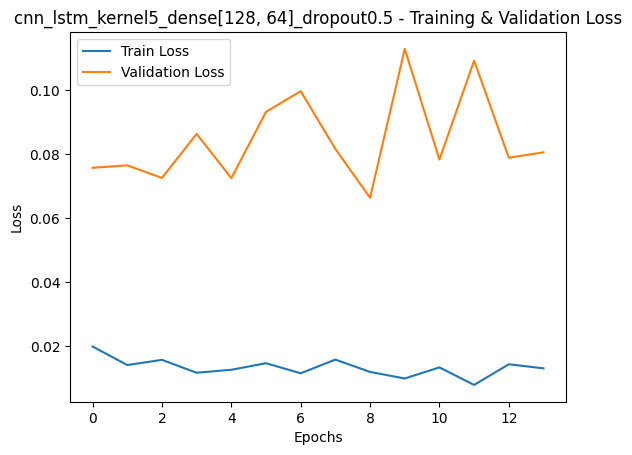

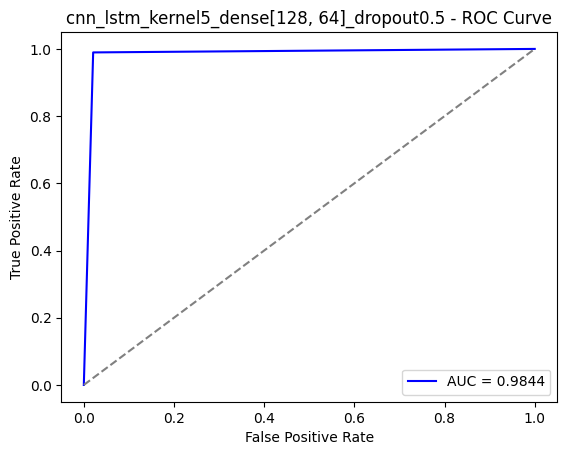

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)             │ ?                           │       1,709,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_12 (Conv1D)                   │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_12 (MaxPooling1D)      │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_4 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_36 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_24 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_37 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_25 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_38 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,709,400 (6.52 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,709,400 (6.52 MB)

2025/03/01 21:48:34 INFO mlflow.tracking.fluent: Experiment with name 'cnn_lstm_kernel5_dense[128, 64]_dropout0.5 with LR 0.0005 and Batch 16' does not exist. Creating a new experiment.


Epoch 1/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 64s 40ms/step - accuracy: 0.8407 - loss: 0.3273 - val_accuracy: 0.9462 - val_loss: 0.1378
Epoch 2/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 81s 39ms/step - accuracy: 0.9760 - loss: 0.0721 - val_accuracy: 0.9721 - val_loss: 0.0851
Epoch 3/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 60s 40ms/step - accuracy: 0.9828 - loss: 0.0540 - val_accuracy: 0.9312 - val_loss: 0.2245
Epoch 4/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 80s 39ms/step - accuracy: 0.9890 - loss: 0.0335 - val_accuracy: 0.9828 - val_loss: 0.0586
Epoch 5/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 82s 39ms/step - accuracy: 0.9912 - loss: 0.0274 - val_accuracy: 0.9840 - val_loss: 0.0525
Epoch 6/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 59s 40ms/step - accuracy: 0.9924 - loss: 0.0230 - val_accuracy: 0.9846 - val_loss: 0.0604
Epoch 7/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 81s 39ms/step - accuracy: 0.9931 - loss: 0.0215 - val_accuracy: 0.9826 - val_loss: 0.0675
Epoch 8/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 82s 39ms/step - accuracy: 0.9932 -

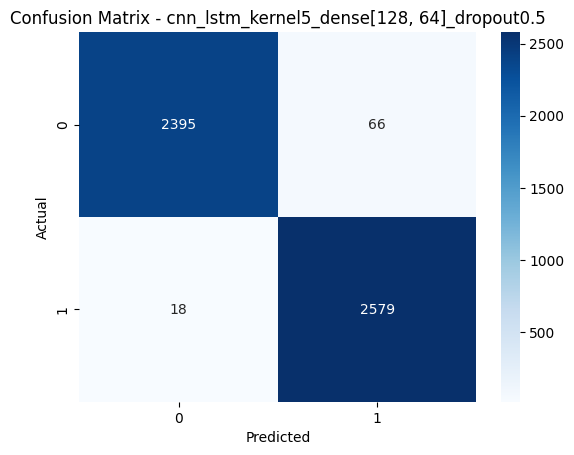

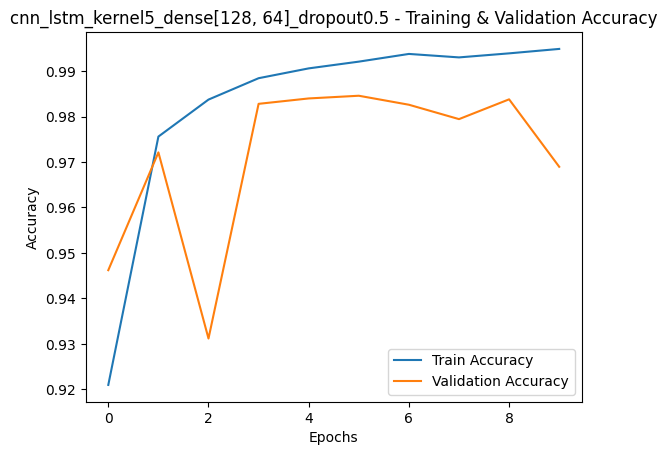

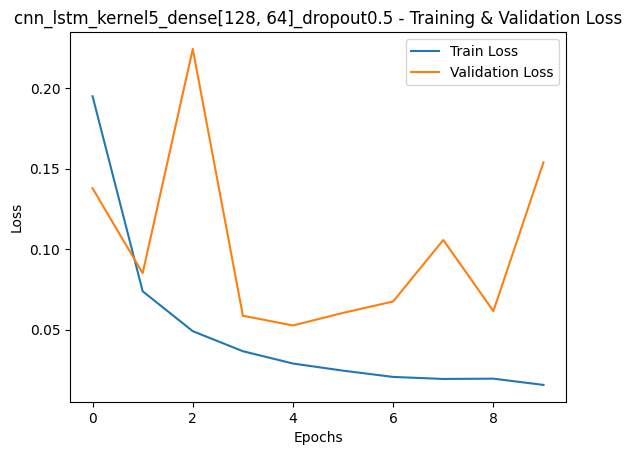

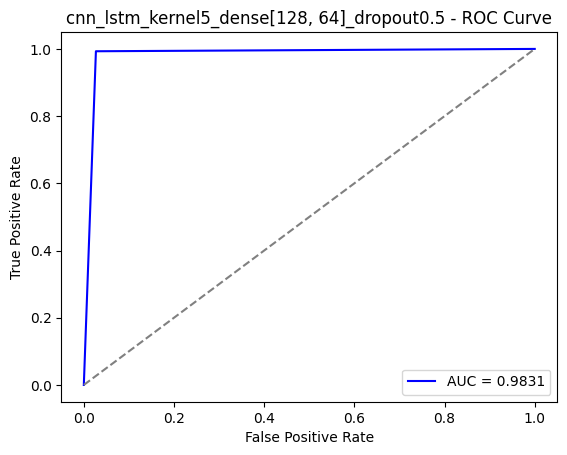

2025/03/01 22:00:53 INFO mlflow.tracking.fluent: Experiment with name 'cnn_lstm_kernel5_dense[128, 64]_dropout0.5 with LR 0.0005 and Batch 32' does not exist. Creating a new experiment.


Epoch 1/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 30s 40ms/step - accuracy: 0.9956 - loss: 0.0135 - val_accuracy: 0.9832 - val_loss: 0.0662
Epoch 2/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 41s 40ms/step - accuracy: 0.9970 - loss: 0.0100 - val_accuracy: 0.9822 - val_loss: 0.0768
Epoch 3/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 41s 40ms/step - accuracy: 0.9955 - loss: 0.0144 - val_accuracy: 0.9846 - val_loss: 0.0721
Epoch 4/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 41s 40ms/step - accuracy: 0.9969 - loss: 0.0121 - val_accuracy: 0.9834 - val_loss: 0.0792
Epoch 5/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 41s 40ms/step - accuracy: 0.9954 - loss: 0.0144 - val_accuracy: 0.9832 - val_loss: 0.0703
Epoch 6/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 41s 40ms/step - accuracy: 0.9972 - loss: 0.0101 - val_accuracy: 0.9836 - val_loss: 0.0799
159/159 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
159/159 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
test_loss: 0.06200794130563736
test_accuracy: 0.9831949472427368
precision: 0.9753974261922785
recall: 0.9922988063149788
f1_score: 0.98

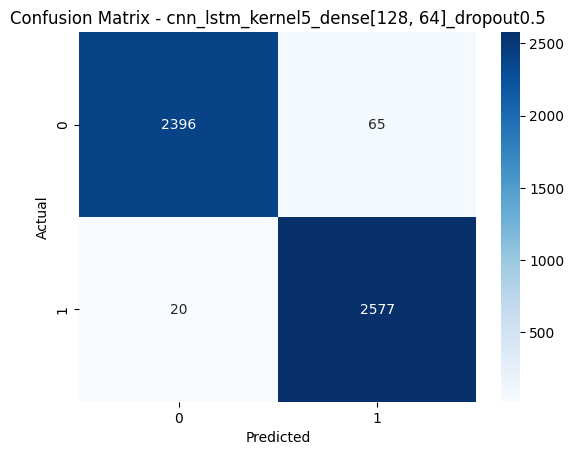

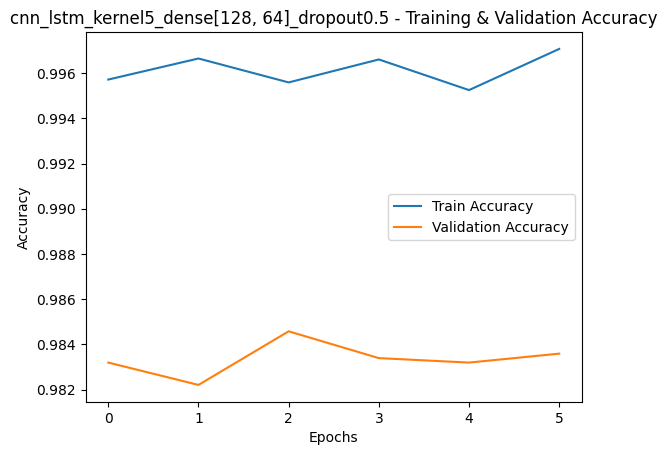

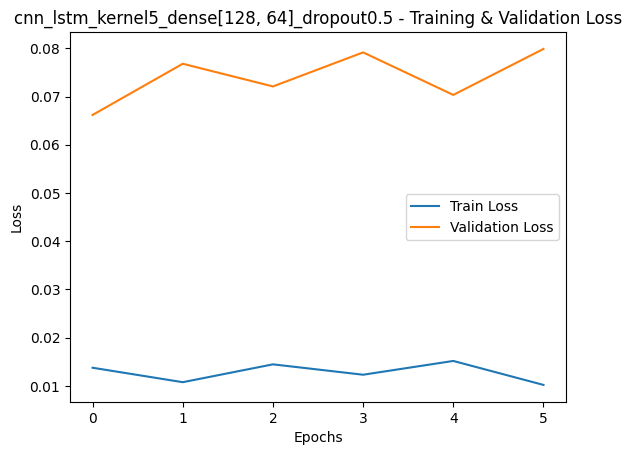

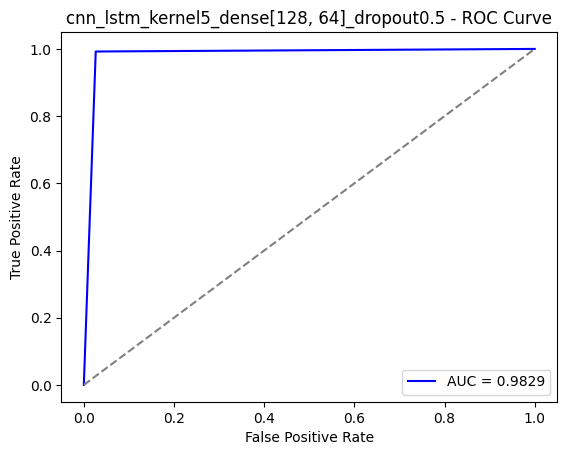

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_13 (Embedding)             │ ?                           │       1,709,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_13 (Conv1D)                   │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_13 (MaxPooling1D)      │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_5 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_39 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_26 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_40 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_27 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_41 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,709,400 (6.52 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,709,400 (6.52 MB)

2025/03/01 22:05:10 INFO mlflow.tracking.fluent: Experiment with name 'cnn_lstm_kernel5_dense[128, 64]_dropout0.5 with LR 0.0001 and Batch 16' does not exist. Creating a new experiment.


Epoch 1/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 67s 43ms/step - accuracy: 0.7918 - loss: 0.4217 - val_accuracy: 0.9616 - val_loss: 0.1106
Epoch 2/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 78s 41ms/step - accuracy: 0.9548 - loss: 0.1378 - val_accuracy: 0.9692 - val_loss: 0.0829
Epoch 3/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 81s 40ms/step - accuracy: 0.9736 - loss: 0.0812 - val_accuracy: 0.9713 - val_loss: 0.0851
Epoch 4/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 83s 41ms/step - accuracy: 0.9841 - loss: 0.0516 - val_accuracy: 0.9794 - val_loss: 0.0591
Epoch 5/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 60s 40ms/step - accuracy: 0.9894 - loss: 0.0340 - val_accuracy: 0.9747 - val_loss: 0.0891
Epoch 6/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 82s 40ms/step - accuracy: 0.9922 - loss: 0.0249 - val_accuracy: 0.9828 - val_loss: 0.0627
Epoch 7/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 82s 40ms/step - accuracy: 0.9922 - loss: 0.0250 - val_accuracy: 0.9610 - val_loss: 0.1465
Epoch 8/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 83s 41ms/step - accuracy: 0.9940 -

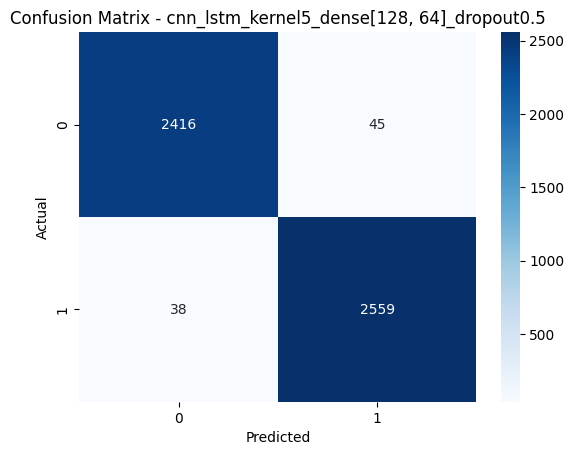

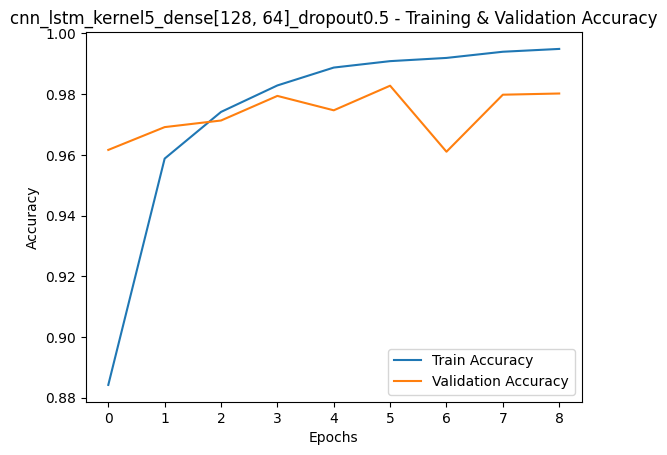

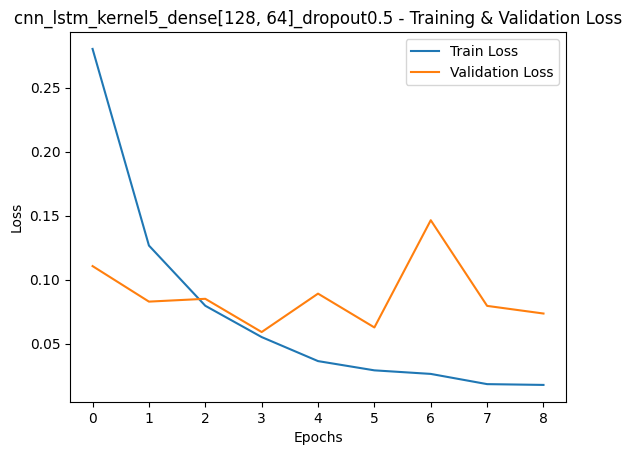

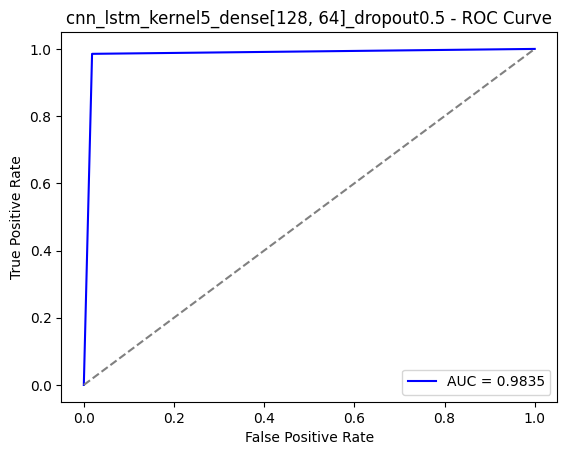

2025/03/01 22:17:23 INFO mlflow.tracking.fluent: Experiment with name 'cnn_lstm_kernel5_dense[128, 64]_dropout0.5 with LR 0.0001 and Batch 32' does not exist. Creating a new experiment.


Epoch 1/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 32s 43ms/step - accuracy: 0.9802 - loss: 0.0635 - val_accuracy: 0.9773 - val_loss: 0.0735
Epoch 2/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.9915 - loss: 0.0260 - val_accuracy: 0.9786 - val_loss: 0.0761
Epoch 3/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 40s 42ms/step - accuracy: 0.9944 - loss: 0.0194 - val_accuracy: 0.9826 - val_loss: 0.0686
Epoch 4/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 42s 43ms/step - accuracy: 0.9952 - loss: 0.0167 - val_accuracy: 0.9822 - val_loss: 0.0758
Epoch 5/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 40s 42ms/step - accuracy: 0.9947 - loss: 0.0186 - val_accuracy: 0.9822 - val_loss: 0.0698
Epoch 6/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - accuracy: 0.9965 - loss: 0.0118 - val_accuracy: 0.9802 - val_loss: 0.0777
Epoch 7/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - accuracy: 0.9959 - loss: 0.0138 - val_accuracy: 0.9739 - val_loss: 0.1446
Epoch 8/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 31s 41ms/step - accuracy: 0.9961 - loss: 0.0116 - 

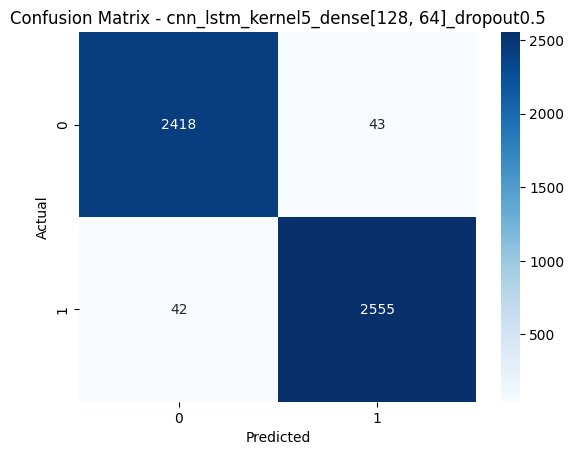

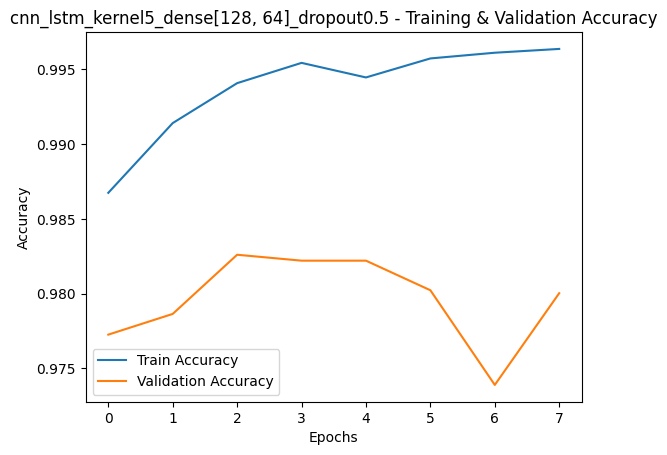

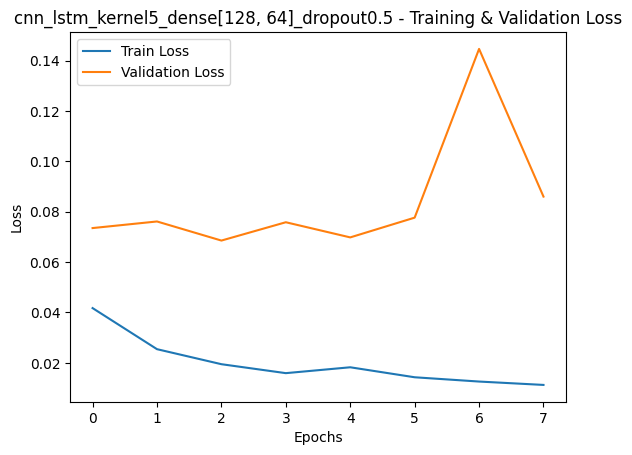

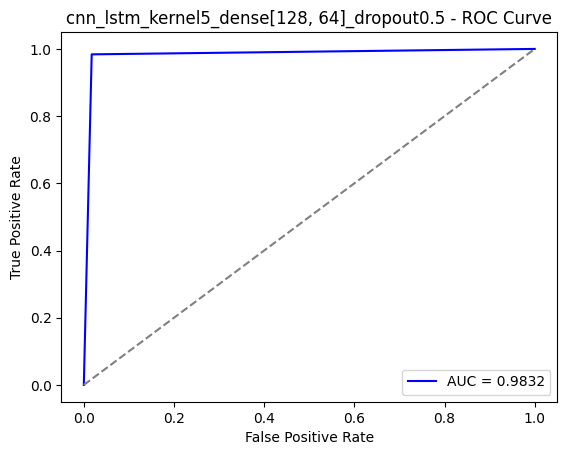

In [ ]:
# CNN + LSTM Model Training
for kernel in KERNEL_SIZE:
  for dense in DENSE:
    for dropout in DROPOUT_RATE:
      for lr in LEARNING_RATES:
        cnn_ltsm_model =  build_cnn_ltsm(vocab_size=len(word_index) + 1,
                                        embedding_matrix=embedding_matrix,
                                        kernel_size = kernel,
                                        filters=dense[0],
                                        dense_units=dense,
                                        dropout_rate=dropout,
                                        learning_rate=lr)
        model_name = f"cnn_lstm_kernel{kernel}_dense{dense}_dropout{dropout}"
        train_and_evaluate(cnn_ltsm_model, model_name, lr,
                            X_train_padded, y_train, X_val_padded, y_val,
                            X_test_padded, y_test)

### LSTM

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_14 (Embedding)             │ ?                           │       1,709,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_6 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_42 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_28 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_43 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_29 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_44 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,709,400 (6.52 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,709,400 (6.52 MB)

2025/03/01 22:22:51 INFO mlflow.tracking.fluent: Experiment with name 'rnn_lstm_dense[256, 128]_dropout0.5 with LR 0.001 and Batch 16' does not exist. Creating a new experiment.


Epoch 1/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 96s 63ms/step - accuracy: 0.8681 - loss: 0.3047 - val_accuracy: 0.9610 - val_loss: 0.1088
Epoch 2/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 142s 63ms/step - accuracy: 0.9660 - loss: 0.0971 - val_accuracy: 0.9585 - val_loss: 0.1192
Epoch 3/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 142s 63ms/step - accuracy: 0.9748 - loss: 0.0785 - val_accuracy: 0.9693 - val_loss: 0.0904
Epoch 4/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 138s 60ms/step - accuracy: 0.9744 - loss: 0.0752 - val_accuracy: 0.9800 - val_loss: 0.0685
Epoch 5/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 142s 60ms/step - accuracy: 0.9788 - loss: 0.0630 - val_accuracy: 0.9775 - val_loss: 0.0676
Epoch 6/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 145s 62ms/step - accuracy: 0.9873 - loss: 0.0387 - val_accuracy: 0.9788 - val_loss: 0.0650
Epoch 7/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 138s 59ms/step - accuracy: 0.9881 - loss: 0.0354 - val_accuracy: 0.9761 - val_loss: 0.0900
Epoch 8/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 88s 60ms/step - accuracy: 0.

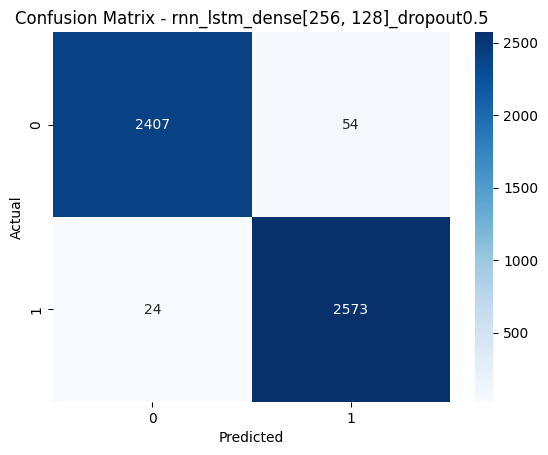

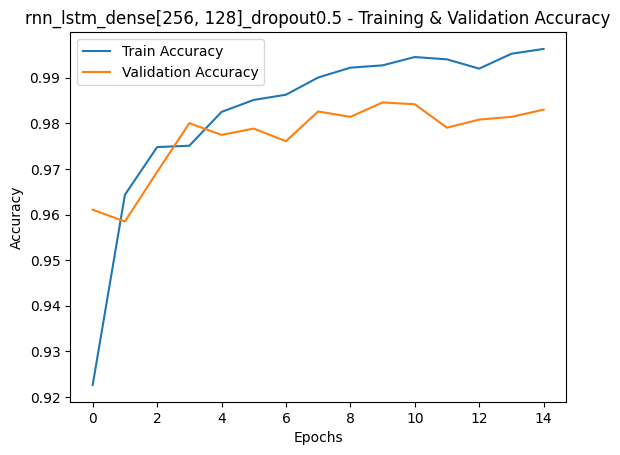

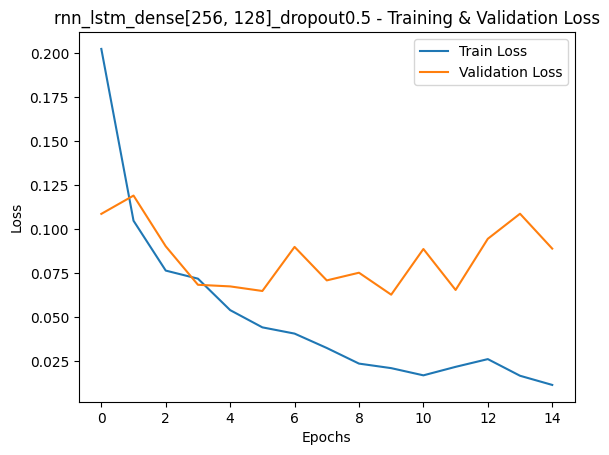

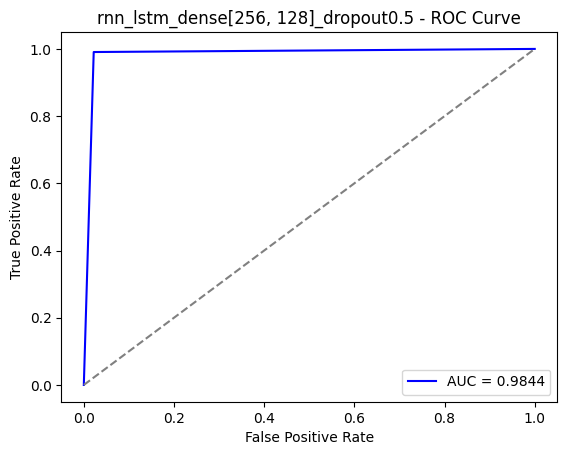

2025/03/01 22:54:22 INFO mlflow.tracking.fluent: Experiment with name 'rnn_lstm_dense[256, 128]_dropout0.5 with LR 0.001 and Batch 32' does not exist. Creating a new experiment.


Epoch 1/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 40s 54ms/step - accuracy: 0.9956 - loss: 0.0129 - val_accuracy: 0.9844 - val_loss: 0.0879
Epoch 2/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 42s 56ms/step - accuracy: 0.9974 - loss: 0.0090 - val_accuracy: 0.9838 - val_loss: 0.0759
Epoch 3/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 42s 56ms/step - accuracy: 0.9967 - loss: 0.0107 - val_accuracy: 0.9852 - val_loss: 0.0952
Epoch 4/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 40s 54ms/step - accuracy: 0.9977 - loss: 0.0070 - val_accuracy: 0.9810 - val_loss: 0.0944
Epoch 5/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 42s 56ms/step - accuracy: 0.9961 - loss: 0.0124 - val_accuracy: 0.9816 - val_loss: 0.0788
Epoch 6/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 81s 55ms/step - accuracy: 0.9962 - loss: 0.0118 - val_accuracy: 0.9808 - val_loss: 0.1026
Epoch 7/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 40s 54ms/step - accuracy: 0.9964 - loss: 0.0126 - val_accuracy: 0.9848 - val_loss: 0.0794
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step
159/159 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step
test_l

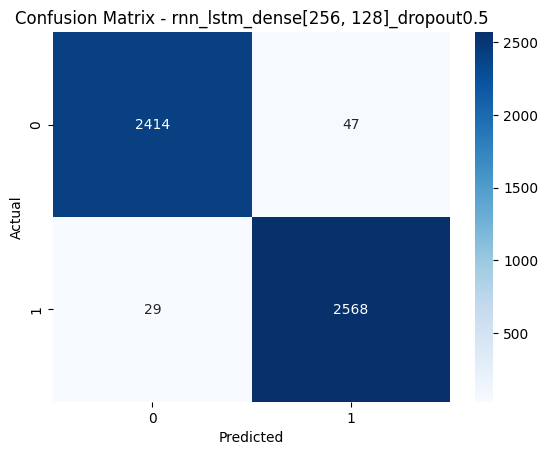

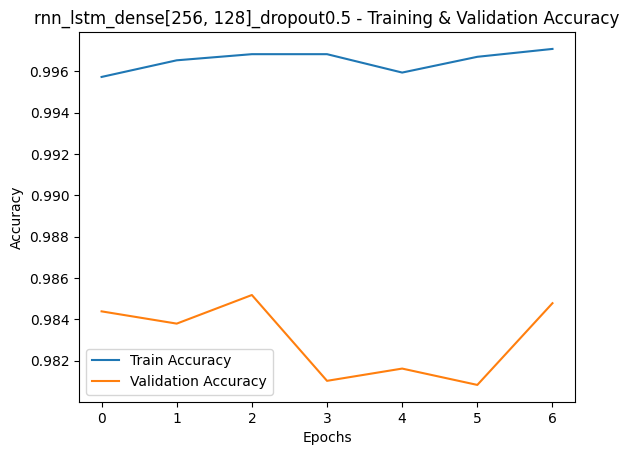

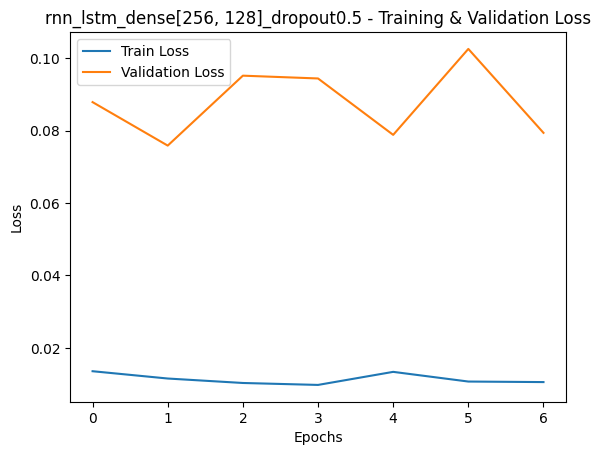

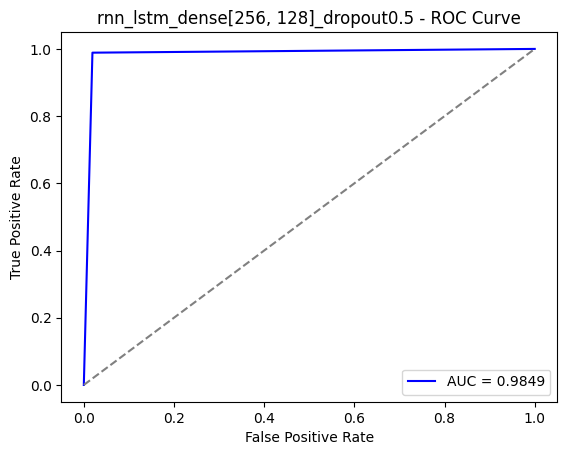

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_15 (Embedding)             │ ?                           │       1,709,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_7 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_45 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_30 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_46 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_31 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_47 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,709,400 (6.52 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,709,400 (6.52 MB)

2025/03/01 23:00:07 INFO mlflow.tracking.fluent: Experiment with name 'rnn_lstm_dense[256, 128]_dropout0.5 with LR 0.0005 and Batch 16' does not exist. Creating a new experiment.


Epoch 1/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 100s 65ms/step - accuracy: 0.8474 - loss: 0.3403 - val_accuracy: 0.9545 - val_loss: 0.1214
Epoch 2/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 92s 62ms/step - accuracy: 0.9567 - loss: 0.1284 - val_accuracy: 0.9620 - val_loss: 0.1090
Epoch 3/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 91s 62ms/step - accuracy: 0.9704 - loss: 0.0858 - val_accuracy: 0.9729 - val_loss: 0.0813
Epoch 4/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 92s 62ms/step - accuracy: 0.9789 - loss: 0.0601 - val_accuracy: 0.9781 - val_loss: 0.0672
Epoch 5/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 146s 64ms/step - accuracy: 0.9855 - loss: 0.0432 - val_accuracy: 0.9796 - val_loss: 0.0610
Epoch 6/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 142s 64ms/step - accuracy: 0.9847 - loss: 0.0457 - val_accuracy: 0.9842 - val_loss: 0.0549
Epoch 7/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 142s 65ms/step - accuracy: 0.9877 - loss: 0.0587 - val_accuracy: 0.9820 - val_loss: 0.0664
Epoch 8/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 91s 62ms/step - accuracy: 0.99

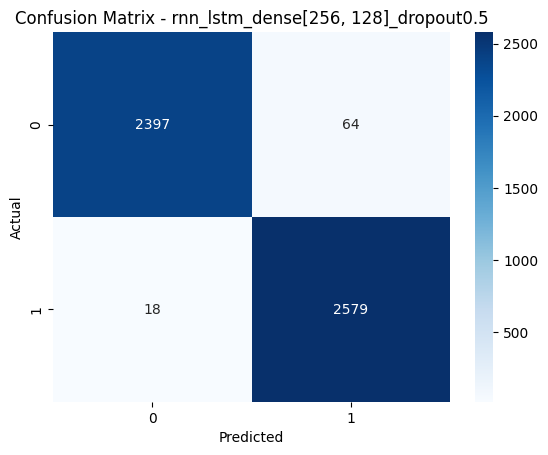

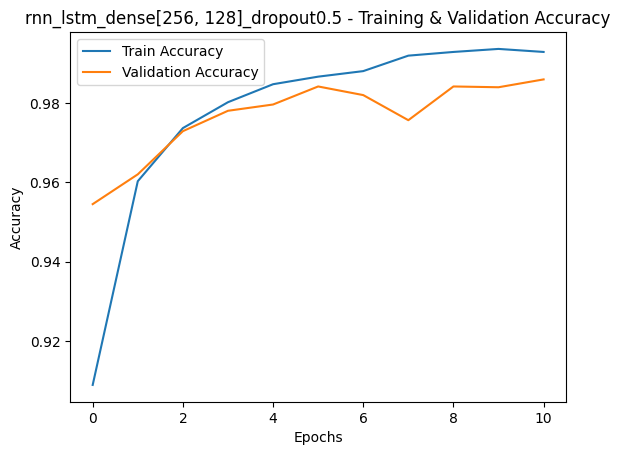

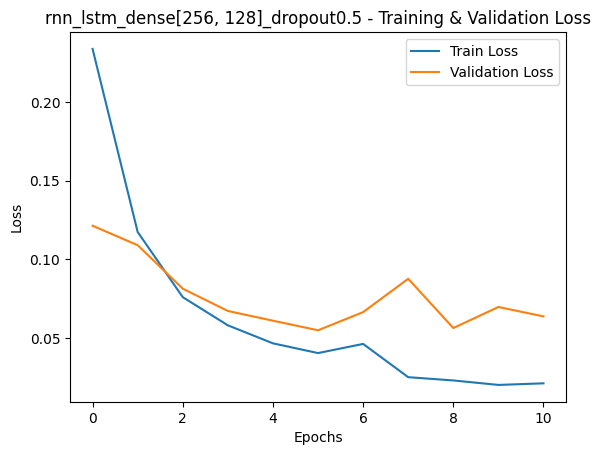

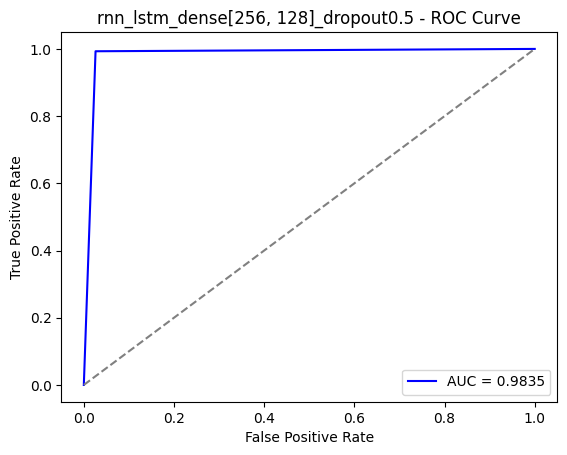

2025/03/01 23:19:53 INFO mlflow.tracking.fluent: Experiment with name 'rnn_lstm_dense[256, 128]_dropout0.5 with LR 0.0005 and Batch 32' does not exist. Creating a new experiment.


Epoch 1/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 42s 57ms/step - accuracy: 0.9909 - loss: 0.0281 - val_accuracy: 0.9816 - val_loss: 0.0655
Epoch 2/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 43s 59ms/step - accuracy: 0.9934 - loss: 0.0192 - val_accuracy: 0.9690 - val_loss: 0.0919
Epoch 3/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 41s 56ms/step - accuracy: 0.9912 - loss: 0.0291 - val_accuracy: 0.9826 - val_loss: 0.0678
Epoch 4/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 84s 59ms/step - accuracy: 0.9947 - loss: 0.0157 - val_accuracy: 0.9826 - val_loss: 0.0670
Epoch 5/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 43s 59ms/step - accuracy: 0.9954 - loss: 0.0162 - val_accuracy: 0.9820 - val_loss: 0.0688
Epoch 6/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 81s 57ms/step - accuracy: 0.9950 - loss: 0.0164 - val_accuracy: 0.9824 - val_loss: 0.0786
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step
test_loss: 0.05757369101047516
test_accuracy: 0.9833926558494568
precision: 0.9739720860052811
recall: 0.9942241047362341
f1_score: 0.98

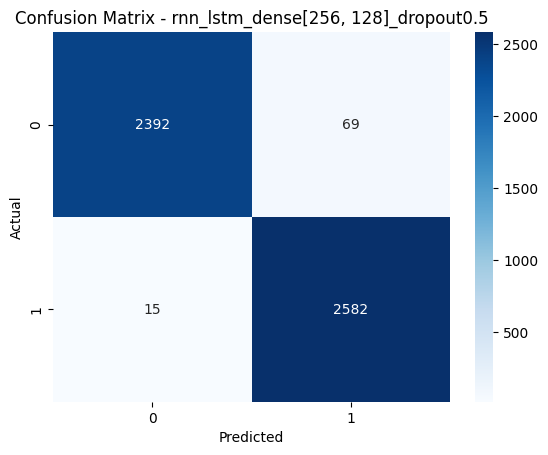

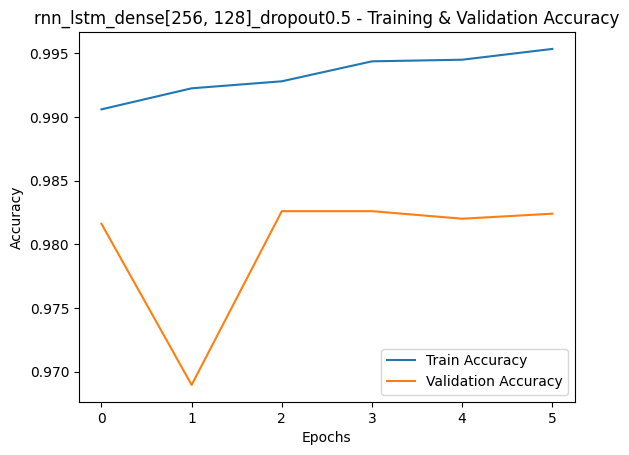

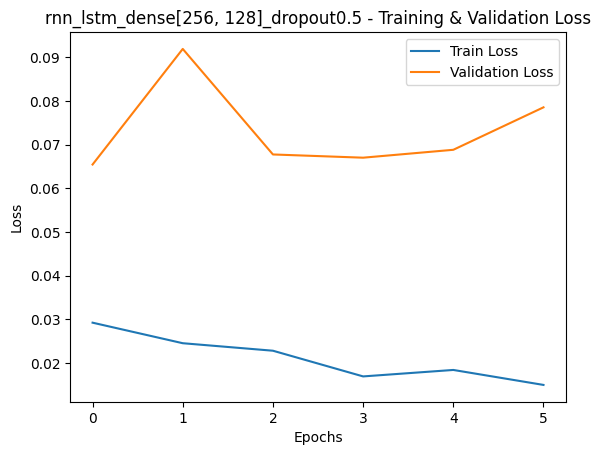

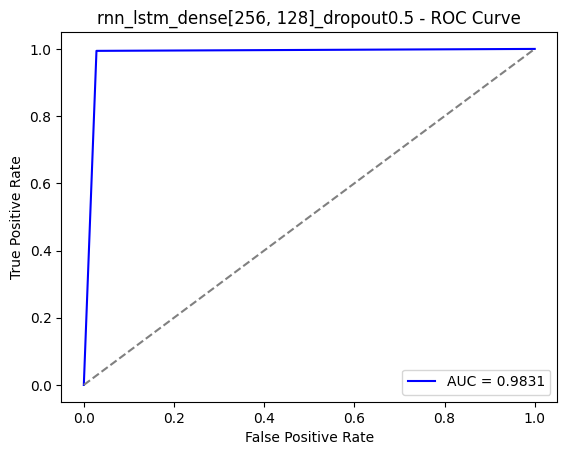

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_16 (Embedding)             │ ?                           │       1,709,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_8 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_48 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_32 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_49 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_33 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_50 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,709,400 (6.52 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,709,400 (6.52 MB)

2025/03/01 23:26:23 INFO mlflow.tracking.fluent: Experiment with name 'rnn_lstm_dense[256, 128]_dropout0.5 with LR 0.0001 and Batch 16' does not exist. Creating a new experiment.


Epoch 1/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 97s 64ms/step - accuracy: 0.7798 - loss: 0.4406 - val_accuracy: 0.9470 - val_loss: 0.1499
Epoch 2/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 140s 63ms/step - accuracy: 0.9401 - loss: 0.1674 - val_accuracy: 0.9205 - val_loss: 0.1958
Epoch 3/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 142s 63ms/step - accuracy: 0.9524 - loss: 0.1319 - val_accuracy: 0.9573 - val_loss: 0.1173
Epoch 4/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 141s 62ms/step - accuracy: 0.9602 - loss: 0.1171 - val_accuracy: 0.9646 - val_loss: 0.0958
Epoch 5/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 97s 65ms/step - accuracy: 0.9631 - loss: 0.1032 - val_accuracy: 0.9715 - val_loss: 0.0838
Epoch 6/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 138s 63ms/step - accuracy: 0.9459 - loss: 0.1401 - val_accuracy: 0.9731 - val_loss: 0.0807
Epoch 7/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 141s 63ms/step - accuracy: 0.9723 - loss: 0.0836 - val_accuracy: 0.9693 - val_loss: 0.0916
Epoch 8/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 97s 66ms/step - accuracy: 0.9

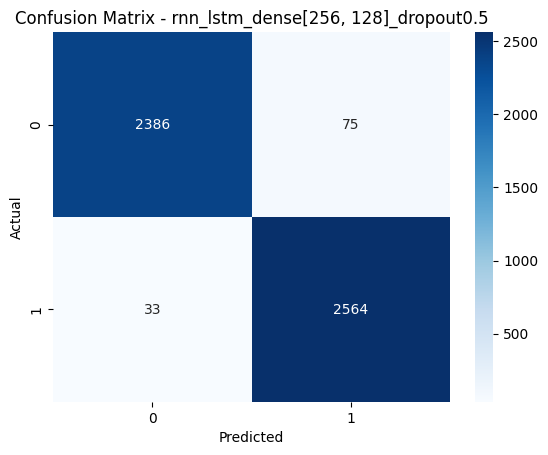

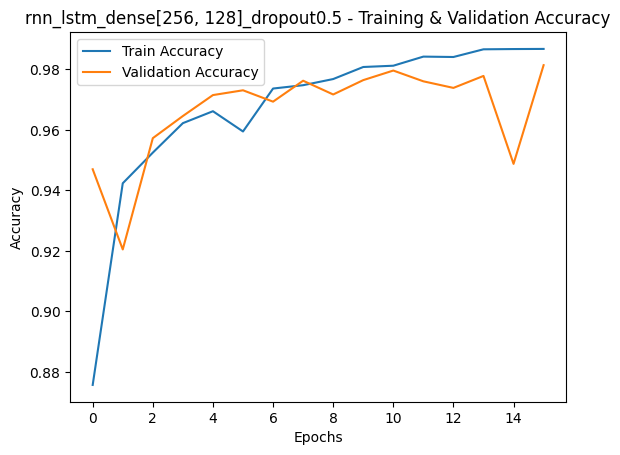

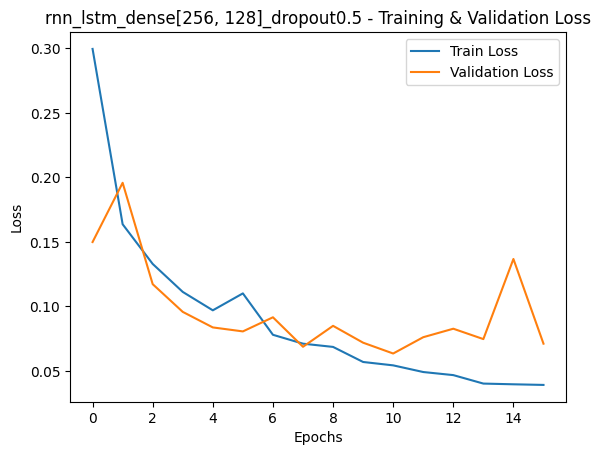

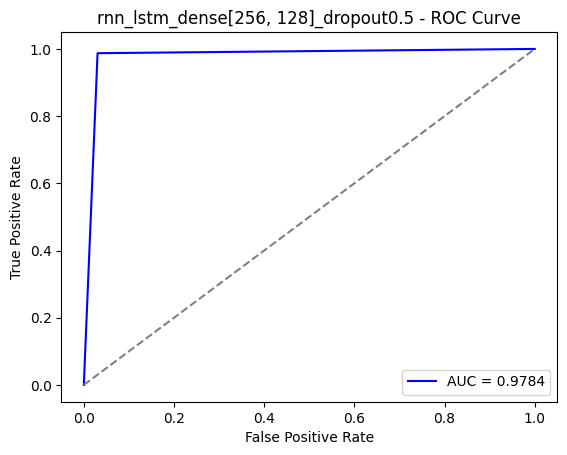

2025/03/02 00:02:03 INFO mlflow.tracking.fluent: Experiment with name 'rnn_lstm_dense[256, 128]_dropout0.5 with LR 0.0001 and Batch 32' does not exist. Creating a new experiment.


Epoch 1/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 44s 59ms/step - accuracy: 0.9854 - loss: 0.0439 - val_accuracy: 0.9753 - val_loss: 0.0832
Epoch 2/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 81s 58ms/step - accuracy: 0.9877 - loss: 0.0401 - val_accuracy: 0.9759 - val_loss: 0.0753
Epoch 3/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 41s 56ms/step - accuracy: 0.9877 - loss: 0.0359 - val_accuracy: 0.9765 - val_loss: 0.0782
Epoch 4/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 41s 56ms/step - accuracy: 0.9872 - loss: 0.0423 - val_accuracy: 0.9727 - val_loss: 0.0798
Epoch 5/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 82s 56ms/step - accuracy: 0.9900 - loss: 0.0319 - val_accuracy: 0.9794 - val_loss: 0.0688
Epoch 6/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 82s 57ms/step - accuracy: 0.9895 - loss: 0.0333 - val_accuracy: 0.9814 - val_loss: 0.0672
Epoch 7/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 82s 57ms/step - accuracy: 0.9893 - loss: 0.0331 - val_accuracy: 0.9820 - val_loss: 0.0648
Epoch 8/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 84s 60ms/step - accuracy: 0.9911 - loss: 0.0296 - 

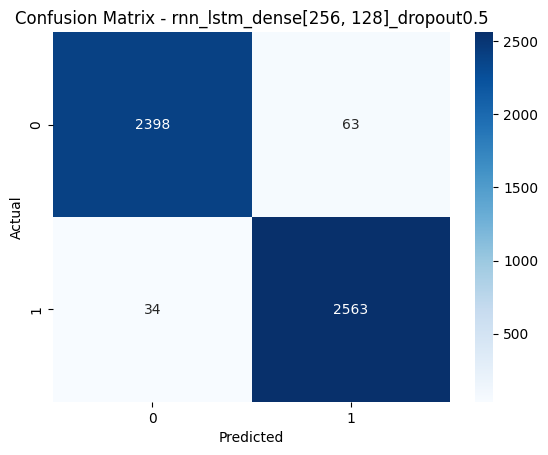

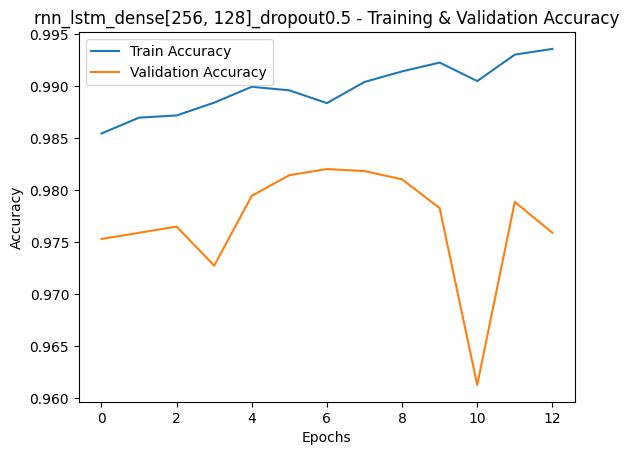

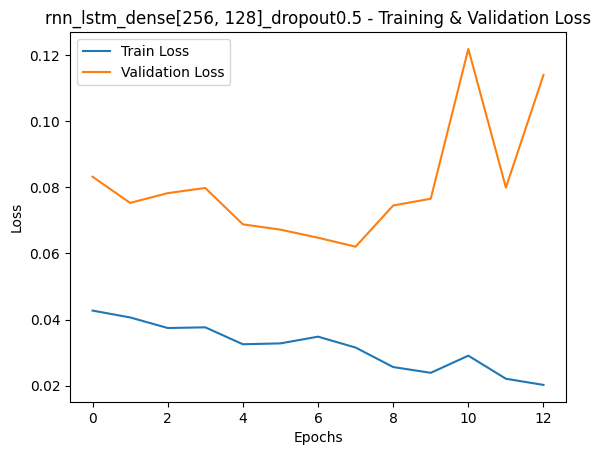

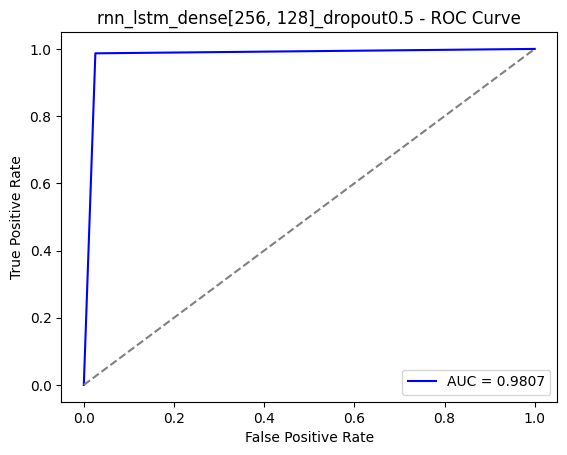

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_17 (Embedding)             │ ?                           │       1,709,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_9 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_51 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_34 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_52 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_35 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_53 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,709,400 (6.52 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,709,400 (6.52 MB)

2025/03/02 00:17:27 INFO mlflow.tracking.fluent: Experiment with name 'rnn_lstm_dense[128, 64]_dropout0.5 with LR 0.001 and Batch 16' does not exist. Creating a new experiment.


Epoch 1/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 101s 67ms/step - accuracy: 0.8574 - loss: 0.3269 - val_accuracy: 0.9646 - val_loss: 0.0971
Epoch 2/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 99s 67ms/step - accuracy: 0.9673 - loss: 0.1037 - val_accuracy: 0.9757 - val_loss: 0.0769
Epoch 3/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 142s 67ms/step - accuracy: 0.9791 - loss: 0.0646 - val_accuracy: 0.9798 - val_loss: 0.0590
Epoch 4/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 139s 65ms/step - accuracy: 0.9849 - loss: 0.0456 - val_accuracy: 0.9834 - val_loss: 0.0557
Epoch 5/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 99s 67ms/step - accuracy: 0.9885 - loss: 0.0325 - val_accuracy: 0.9820 - val_loss: 0.0579
Epoch 6/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 142s 67ms/step - accuracy: 0.9915 - loss: 0.0284 - val_accuracy: 0.9824 - val_loss: 0.0605
Epoch 7/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 138s 64ms/step - accuracy: 0.9938 - loss: 0.0191 - val_accuracy: 0.9836 - val_loss: 0.0576
Epoch 8/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 93s 63ms/step - accuracy: 0.9

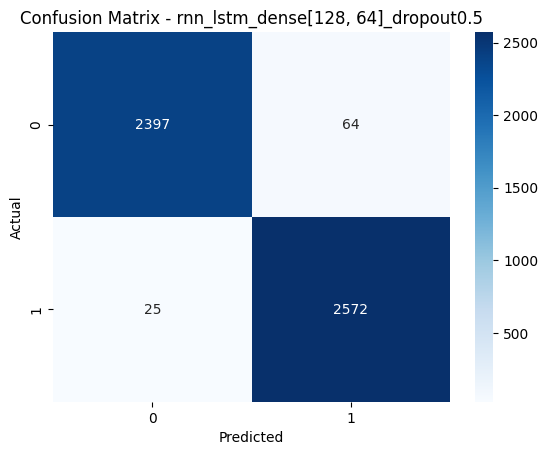

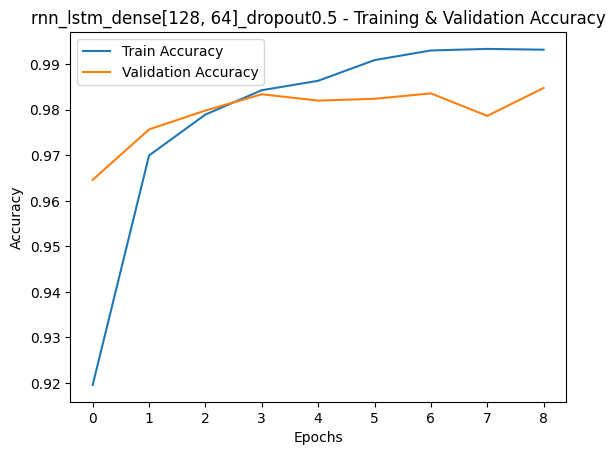

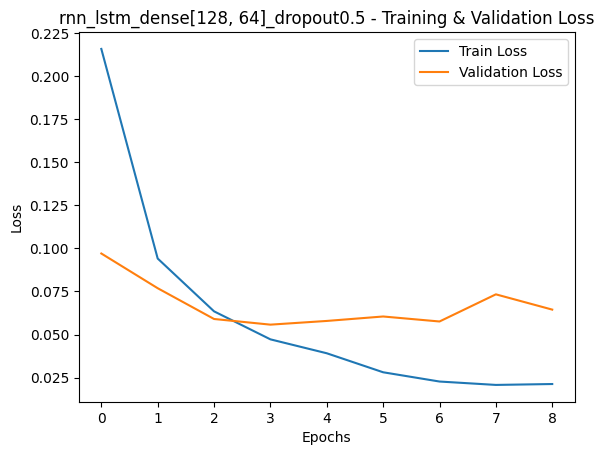

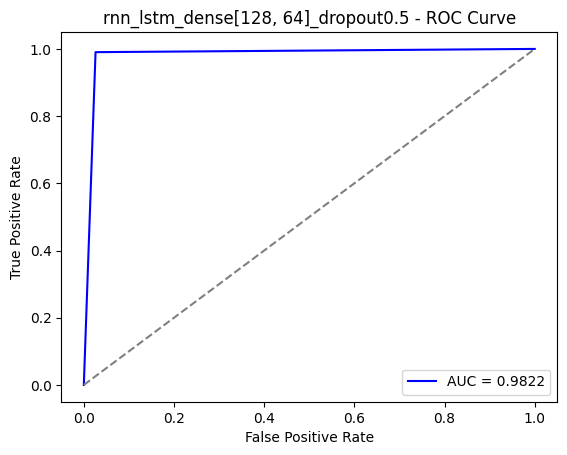

2025/03/02 00:36:44 INFO mlflow.tracking.fluent: Experiment with name 'rnn_lstm_dense[128, 64]_dropout0.5 with LR 0.001 and Batch 32' does not exist. Creating a new experiment.


Epoch 1/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 43s 58ms/step - accuracy: 0.9905 - loss: 0.0297 - val_accuracy: 0.9856 - val_loss: 0.0522
Epoch 2/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 82s 58ms/step - accuracy: 0.9941 - loss: 0.0178 - val_accuracy: 0.9842 - val_loss: 0.0605
Epoch 3/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 82s 58ms/step - accuracy: 0.9935 - loss: 0.0227 - val_accuracy: 0.9838 - val_loss: 0.0626
Epoch 4/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 83s 59ms/step - accuracy: 0.9949 - loss: 0.0153 - val_accuracy: 0.9854 - val_loss: 0.0674
Epoch 5/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 80s 57ms/step - accuracy: 0.9963 - loss: 0.0132 - val_accuracy: 0.9832 - val_loss: 0.0763
Epoch 6/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 85s 61ms/step - accuracy: 0.9961 - loss: 0.0142 - val_accuracy: 0.9844 - val_loss: 0.0672
159/159 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step
test_loss: 0.05488169938325882
test_accuracy: 0.9833926558494568
precision: 0.9750472589792061
recall: 0.9930689256834809
f1_score: 0.98

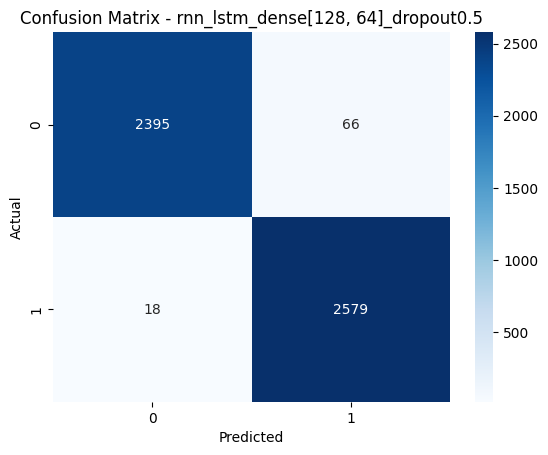

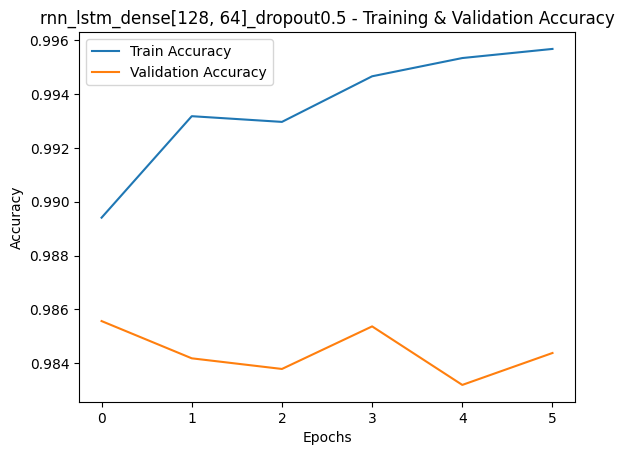

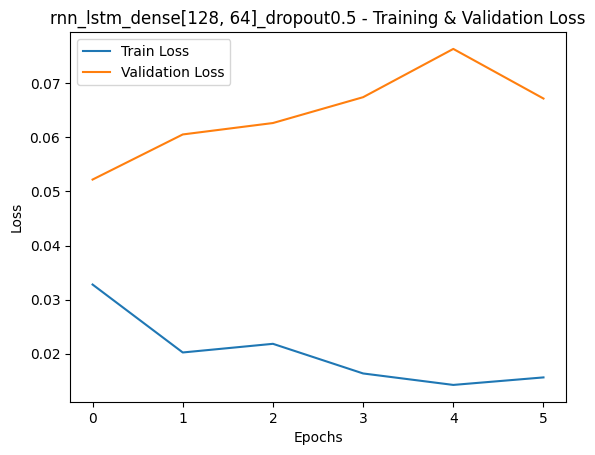

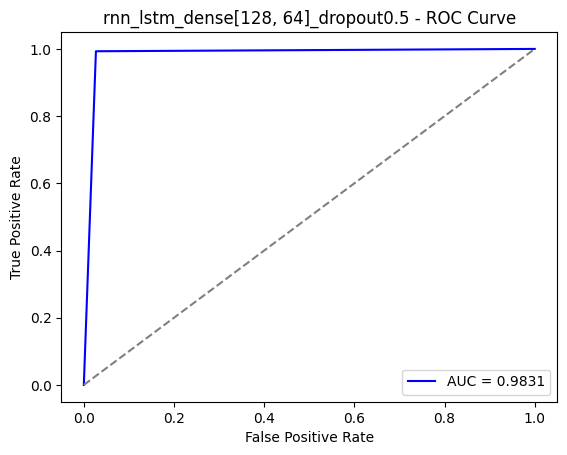

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_18 (Embedding)             │ ?                           │       1,709,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_10 (Bidirectional)     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_54 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_36 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_55 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_37 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_56 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,709,400 (6.52 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,709,400 (6.52 MB)

2025/03/02 00:44:35 INFO mlflow.tracking.fluent: Experiment with name 'rnn_lstm_dense[128, 64]_dropout0.5 with LR 0.0005 and Batch 16' does not exist. Creating a new experiment.


Epoch 1/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 100s 66ms/step - accuracy: 0.8393 - loss: 0.3550 - val_accuracy: 0.9508 - val_loss: 0.1349
Epoch 2/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 141s 65ms/step - accuracy: 0.9465 - loss: 0.1549 - val_accuracy: 0.9715 - val_loss: 0.0804
Epoch 3/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 95s 64ms/step - accuracy: 0.9720 - loss: 0.0845 - val_accuracy: 0.9759 - val_loss: 0.0696
Epoch 4/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 147s 67ms/step - accuracy: 0.9750 - loss: 0.0770 - val_accuracy: 0.9680 - val_loss: 0.0985
Epoch 5/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 142s 67ms/step - accuracy: 0.9752 - loss: 0.0771 - val_accuracy: 0.9717 - val_loss: 0.0869
Epoch 6/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 142s 67ms/step - accuracy: 0.9840 - loss: 0.0468 - val_accuracy: 0.9804 - val_loss: 0.0630
Epoch 7/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 99s 67ms/step - accuracy: 0.9880 - loss: 0.0378 - val_accuracy: 0.9806 - val_loss: 0.0717
Epoch 8/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 99s 67ms/step - accuracy: 0.9

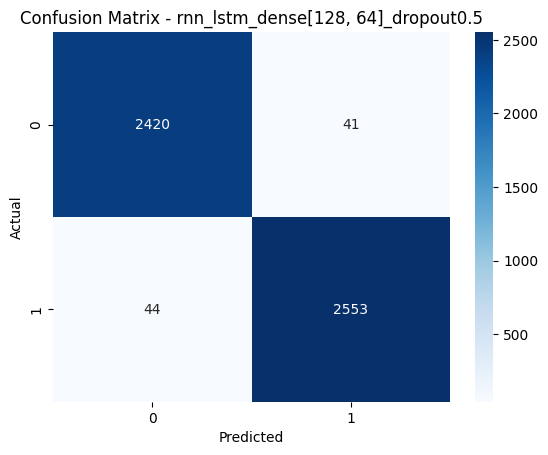

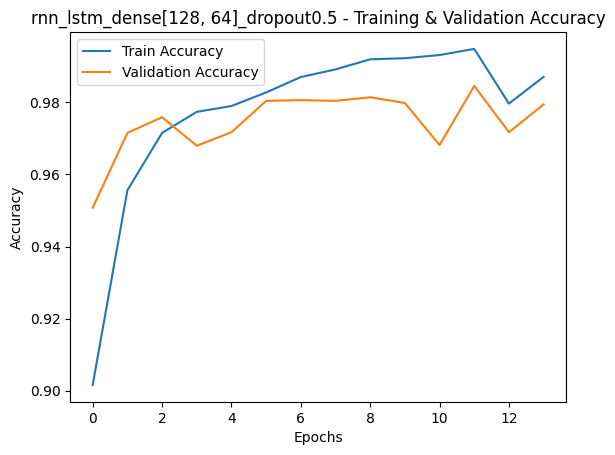

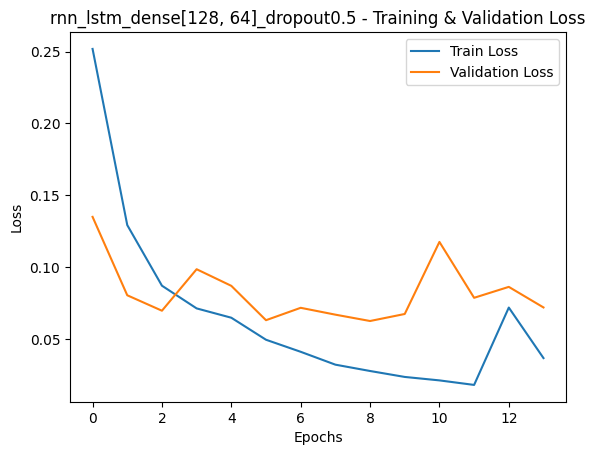

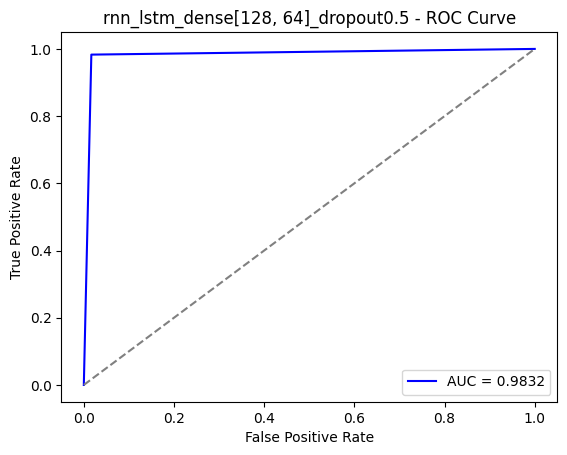

2025/03/02 01:15:04 INFO mlflow.tracking.fluent: Experiment with name 'rnn_lstm_dense[128, 64]_dropout0.5 with LR 0.0005 and Batch 32' does not exist. Creating a new experiment.


Epoch 1/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 46s 62ms/step - accuracy: 0.9937 - loss: 0.0200 - val_accuracy: 0.9798 - val_loss: 0.0908
Epoch 2/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 82s 62ms/step - accuracy: 0.9960 - loss: 0.0127 - val_accuracy: 0.9838 - val_loss: 0.0713
Epoch 3/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 80s 59ms/step - accuracy: 0.9963 - loss: 0.0111 - val_accuracy: 0.9842 - val_loss: 0.0774
Epoch 4/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 44s 59ms/step - accuracy: 0.9963 - loss: 0.0122 - val_accuracy: 0.9840 - val_loss: 0.0813
Epoch 5/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 83s 61ms/step - accuracy: 0.9971 - loss: 0.0091 - val_accuracy: 0.9846 - val_loss: 0.0873
Epoch 6/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 82s 62ms/step - accuracy: 0.9978 - loss: 0.0081 - val_accuracy: 0.9826 - val_loss: 0.1138
Epoch 7/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 82s 62ms/step - accuracy: 0.9971 - loss: 0.0096 - val_accuracy: 0.9856 - val_loss: 0.0912
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step
159/159 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step
test_l

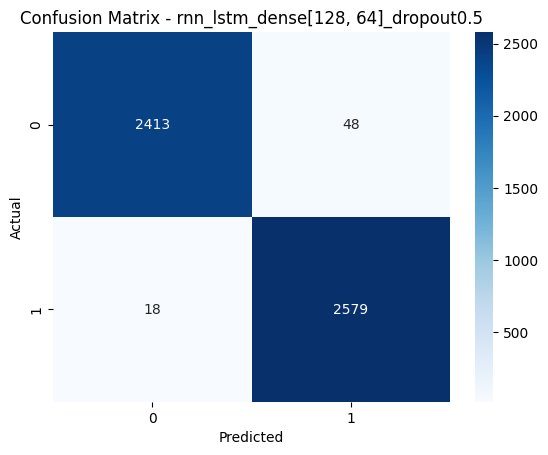

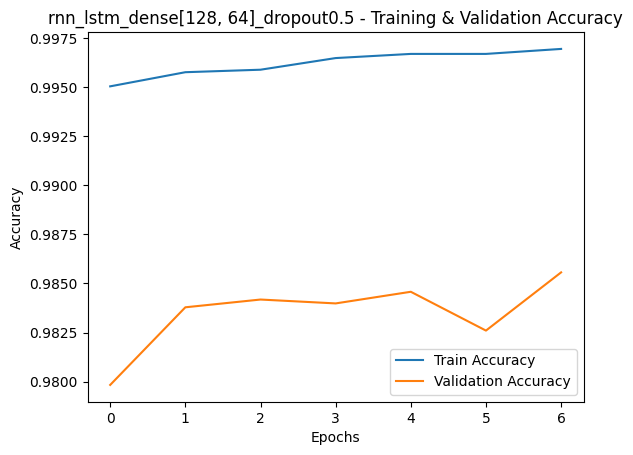

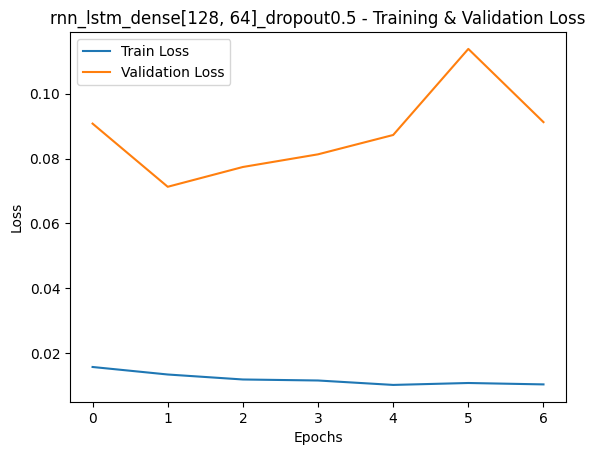

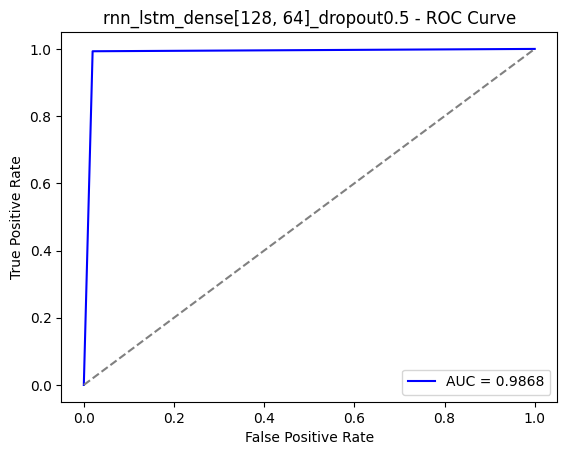

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_19 (Embedding)             │ ?                           │       1,709,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_11 (Bidirectional)     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_57 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_38 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_58 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_39 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_59 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,709,400 (6.52 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,709,400 (6.52 MB)

2025/03/02 01:23:40 INFO mlflow.tracking.fluent: Experiment with name 'rnn_lstm_dense[128, 64]_dropout0.5 with LR 0.0001 and Batch 16' does not exist. Creating a new experiment.


Epoch 1/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 106s 70ms/step - accuracy: 0.7456 - loss: 0.4797 - val_accuracy: 0.9413 - val_loss: 0.1716
Epoch 2/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 137s 66ms/step - accuracy: 0.9396 - loss: 0.1839 - val_accuracy: 0.9500 - val_loss: 0.1390
Epoch 3/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 146s 69ms/step - accuracy: 0.9505 - loss: 0.1495 - val_accuracy: 0.9464 - val_loss: 0.1449
Epoch 4/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 138s 66ms/step - accuracy: 0.9512 - loss: 0.1438 - val_accuracy: 0.8456 - val_loss: 0.3825
Epoch 5/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 102s 69ms/step - accuracy: 0.8922 - loss: 0.2724 - val_accuracy: 0.9583 - val_loss: 0.1184
Epoch 6/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 142s 69ms/step - accuracy: 0.9562 - loss: 0.1291 - val_accuracy: 0.9652 - val_loss: 0.1038
Epoch 7/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 142s 69ms/step - accuracy: 0.9582 - loss: 0.1223 - val_accuracy: 0.9624 - val_loss: 0.1034
Epoch 8/50
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 142s 69ms/step - accuracy: 

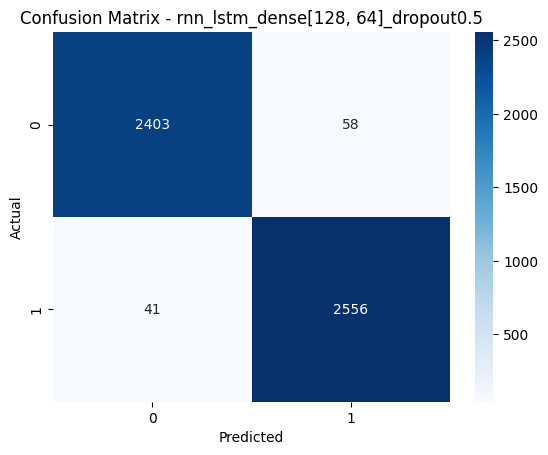

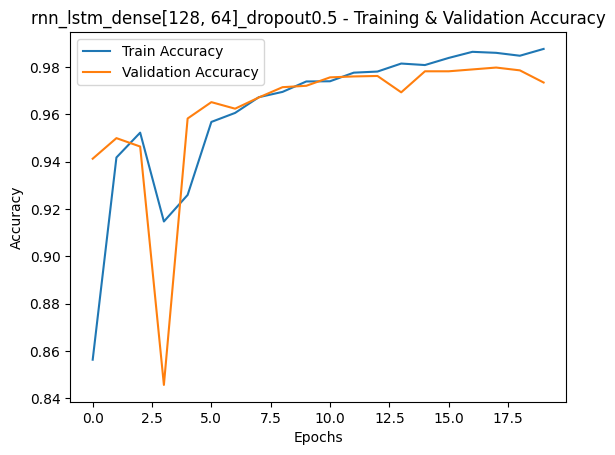

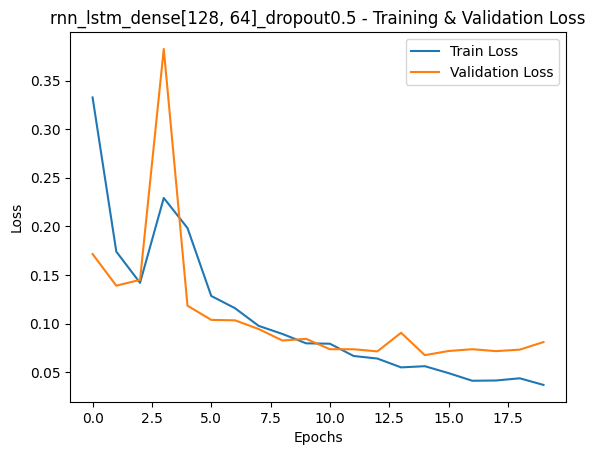

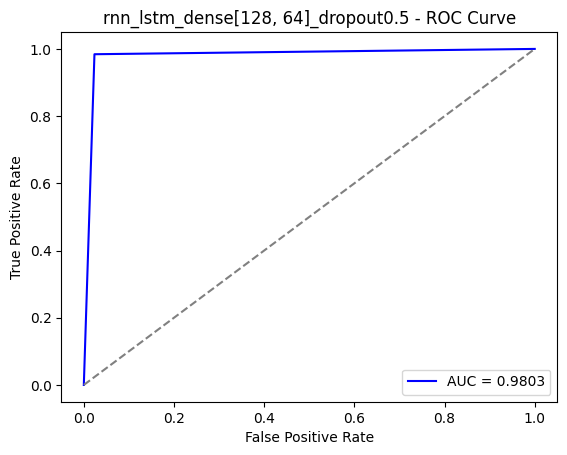

2025/03/02 02:08:28 INFO mlflow.tracking.fluent: Experiment with name 'rnn_lstm_dense[128, 64]_dropout0.5 with LR 0.0001 and Batch 32' does not exist. Creating a new experiment.


Epoch 1/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 47s 64ms/step - accuracy: 0.9876 - loss: 0.0387 - val_accuracy: 0.9796 - val_loss: 0.0685
Epoch 2/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 83s 65ms/step - accuracy: 0.9873 - loss: 0.0373 - val_accuracy: 0.9800 - val_loss: 0.0683
Epoch 3/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 46s 62ms/step - accuracy: 0.9891 - loss: 0.0323 - val_accuracy: 0.9767 - val_loss: 0.0744
Epoch 4/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 46s 62ms/step - accuracy: 0.9875 - loss: 0.0415 - val_accuracy: 0.9816 - val_loss: 0.0718
Epoch 5/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 82s 62ms/step - accuracy: 0.9899 - loss: 0.0330 - val_accuracy: 0.9781 - val_loss: 0.0744
Epoch 6/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 46s 62ms/step - accuracy: 0.9904 - loss: 0.0310 - val_accuracy: 0.9790 - val_loss: 0.0800
Epoch 7/50
738/738 ━━━━━━━━━━━━━━━━━━━━ 82s 63ms/step - accuracy: 0.9916 - loss: 0.0260 - val_accuracy: 0.9735 - val_loss: 0.1007
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step
159/159 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step
test_l

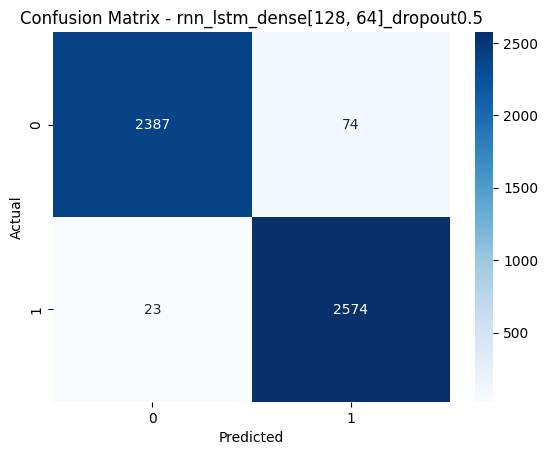

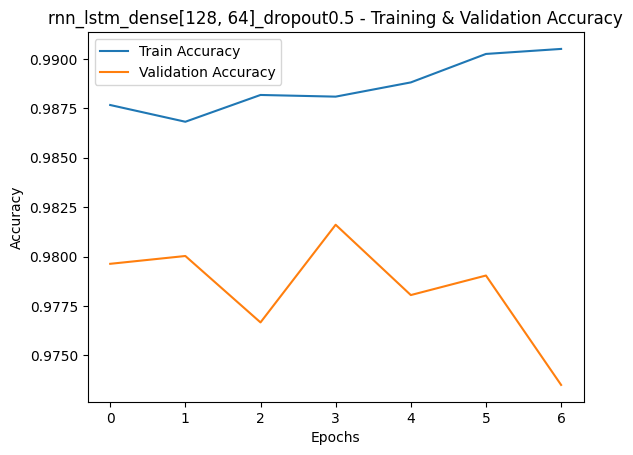

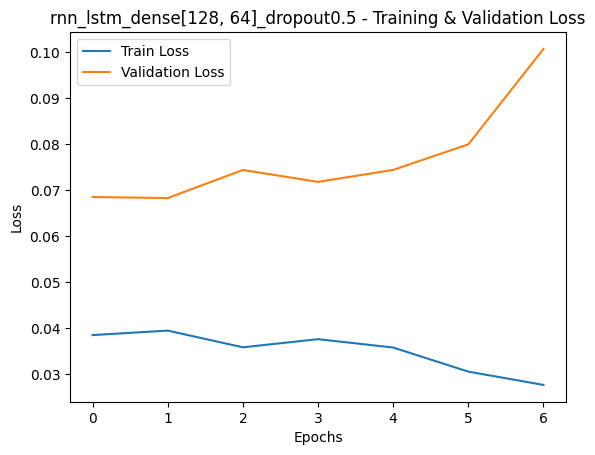

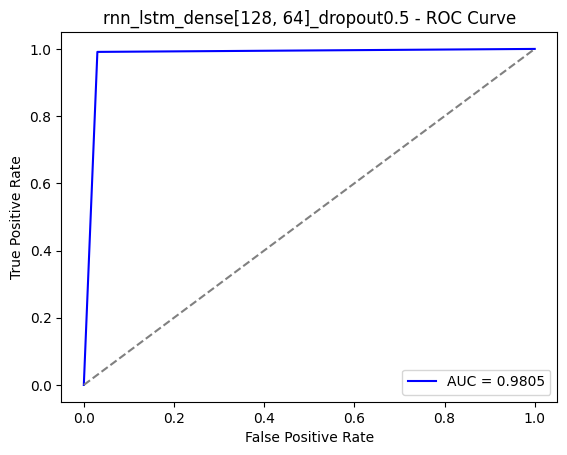

In [ ]:
# LSTM Model Training
for dense in DENSE:
  for dropout in DROPOUT_RATE:
    for lr in LEARNING_RATES:
      rnn_ltsm_model =  build_rnn_lstm(vocab_size=len(word_index) + 1,
                                        embedding_matrix=embedding_matrix,
                                        dense_units=dense,
                                        dropout_rate=dropout,
                                        learning_rate=lr)
      model_name =  f"rnn_lstm_dense{dense}_dropout{dropout}"
      train_and_evaluate(rnn_ltsm_model, model_name, lr,
                        X_train_padded, y_train, X_val_padded, y_val,
                        X_test_padded, y_test)